  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: Tesla T4 (CUDA)
Device: cuda
  v4 from_taxonomy signature OK: ['taxonomy_df', 'feature_cols', 'grid_size_0', 'grid_size_12', 'spline_order', 'grid_range']
Setup complete.
Arms:
  v1: G=14, defective init, eps=0.1, 70 trials
  v2: G=14, fixed, 0 trials
  v3: G=14, fixed, 16 trials
  v4: G=3 L0 / G=14 L1-2, fixed, 70 trials
PART 1a: REPRODUCE SAVED METRICS (must PASS before proceeding)
  v1/agg_full_moments/Split_A/seed42: recomputed=-0.1170 saved=-0.1170  PASS
  v3/agg_full_moments/Split_D/seed42: recomputed=-0.3927 saved=-0.3927  PASS
  v4/agg_full_moments/Split_A/seed42: recomputed=-0.0294 saved=-0.0294  PASS
  v4/agg_means/Split_C/seed456: recomputed=-0.2400 saved=-0.2400  PASS

PART 1b: THEOREM 1 LEDGER IDENTITY ON 

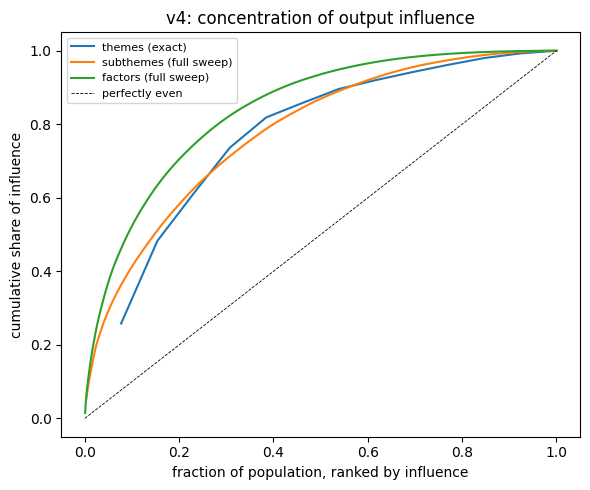


PART 10b: SEED STABILITY OF THEME IMPORTANCE (amplitude, not shape)
  Correlation is scale-free and cannot see this. v2 gave a median
  amplitude ratio of 5.0x (worst 54x). Does v4 improve on it?

  v2: median amplitude ratio = 5.0x  (max 54.1x, n_seeds=3)

  v3: median amplitude ratio = 7.3x  (max 20.1x, n_seeds=3)

  v4: median amplitude ratio = 5.2x  (max 57.4x, n_seeds=3)

Per-theme amplitude ratio by arm:
arm                                         v2    v3         v4
theme                                                          
01 Analyst Expectations & Sentiment   2.500000   3.9   7.400000
02 Credit Conditions                  9.400000   6.2  11.300000
03 Cross-Sectional Risk Profile       5.000000   8.0   6.300000
04 Global Markets, FX & Commodities   5.000000  17.4   5.200000
05 Interest Rates & Monetary Policy  12.600000   8.3  26.400000
06 Investment & Corporate Structure   3.600000   7.2   5.200000
07 Liquidity & Market Quality        13.200000  20.1   2.700000
08 Macroe

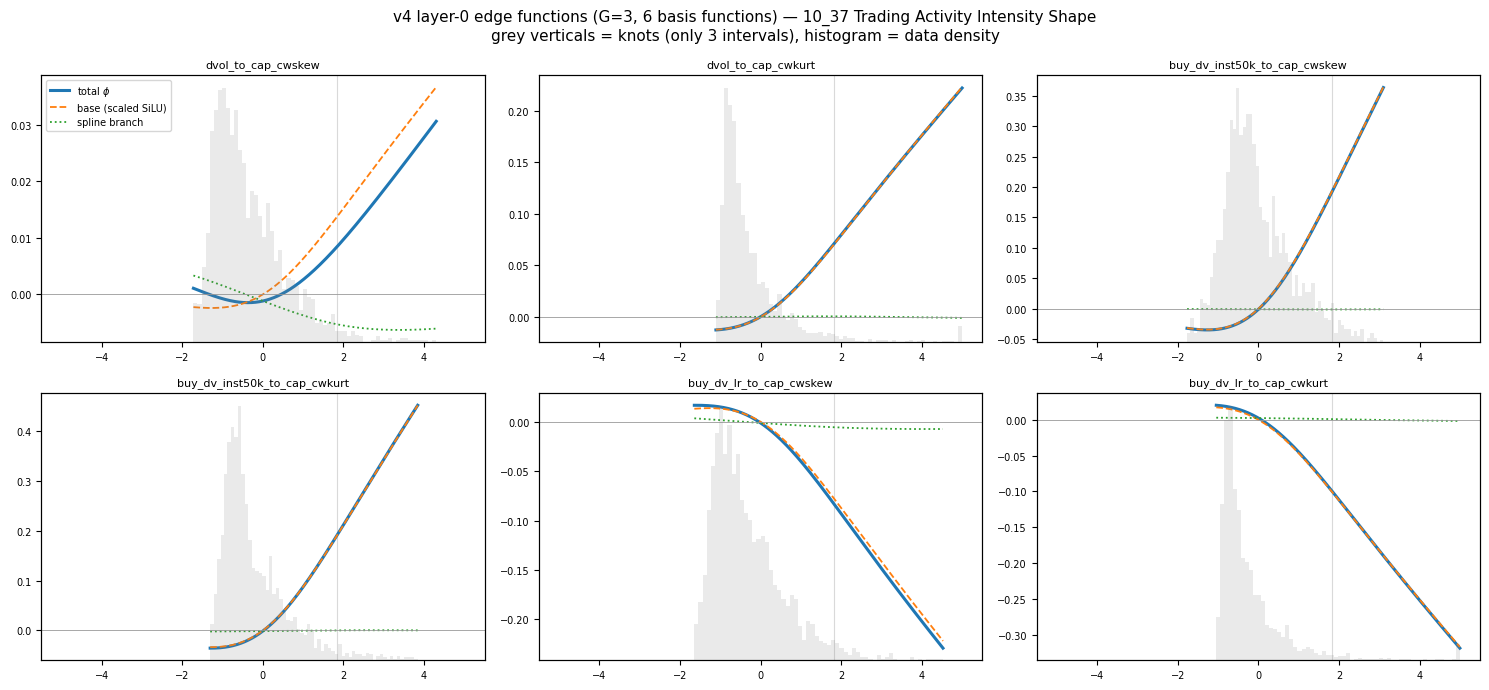

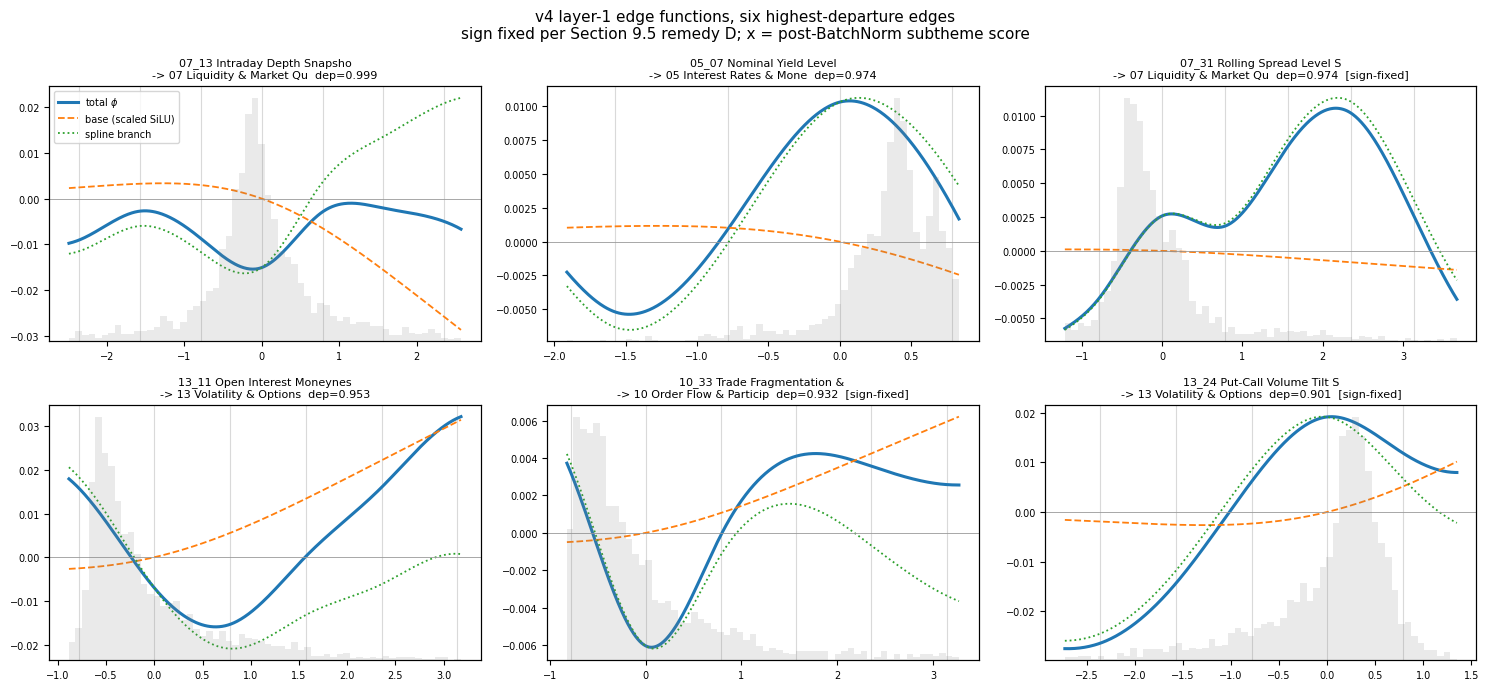

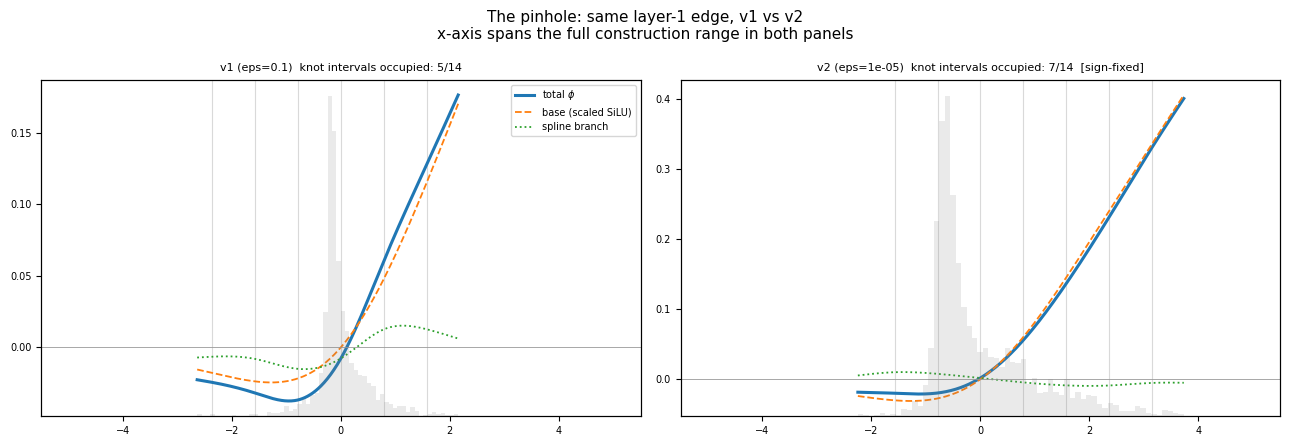

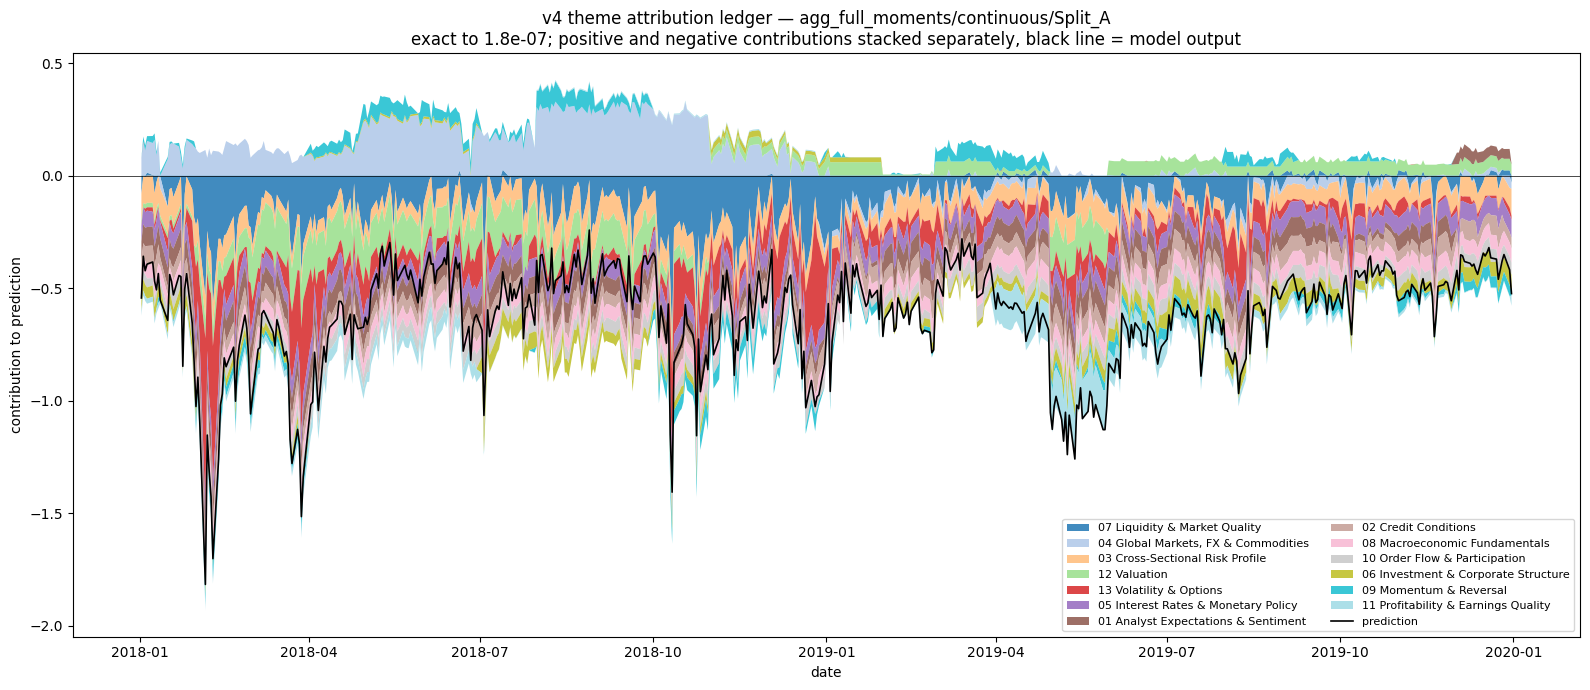

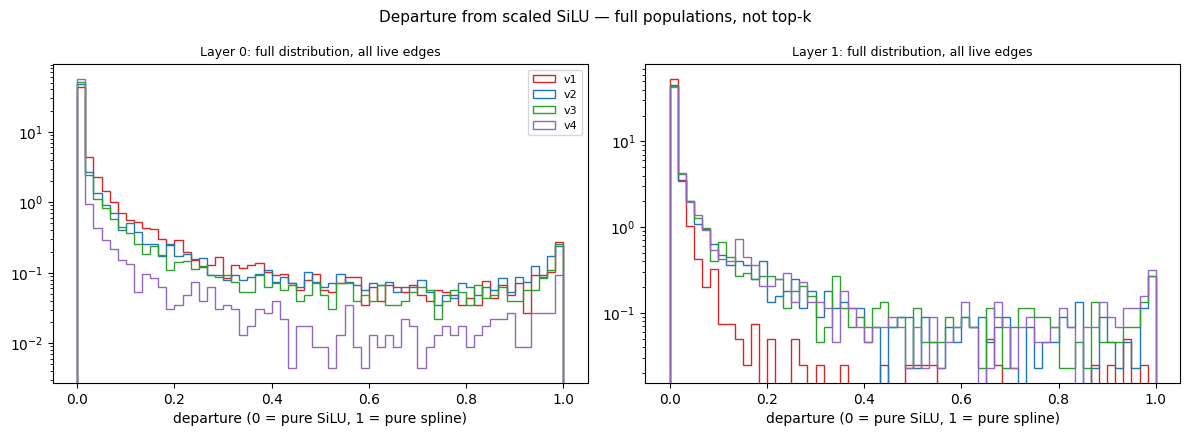


Tables:  /content/drive/MyDrive/Thesis/Data/Results/Dense_vs_Sparse_KAN_v2/v4_analysis/tables
Figures: /content/drive/MyDrive/Thesis/Data/Results/Dense_vs_Sparse_KAN_v2/v4_analysis/figures

NOTEBOOK COMPLETE


In [2]:
# %% [markdown]
# # 17 — Sparse KAN v4: Full Diagnostic and Interpretability Analysis
#
# ═══════════════════════════════════════════════════════════════════════════
# WHAT THIS NOTEBOOK DOES
# ═══════════════════════════════════════════════════════════════════════════
#
# Extends every diagnostic previously run on v1/v2/v3 to include v4
# (G=3 at layer 0, G=14 at layers 1/2), and adds four analyses that only
# became possible or meaningful once v4 existed.
#
# ARMS COMPARED
#   v1  sparse_kan/       defective init, eps=0.1,  G=14 all layers, 70 trials
#   v2  sparse_kan_v2/    fixed init,     eps=1e-5, G=14 all layers,  0 trials
#   v3  sparse_kan_v3/    fixed init,     eps=1e-5, G=14 all layers, 16 trials
#   v4  sparse_kan_v4/    fixed init,     eps=1e-5, G=3 L0 / G=14 L1,2, 70 trials
#   (plus sparse_mlp / sparse_mlp_v2 for the MSE table only)
#
# WHY EACH PART EXISTS
#
#   Part 1  Verification. Reproduce saved metrics exactly before trusting
#           anything. Four spot-checks across arms/datasets/seeds, plus the
#           Theorem 1 ledger identity on v4 (mandatory before any
#           attribution figure is produced from v4 checkpoints).
#
#   Part 2  Exact MSE for every arm, read from SAVED metrics rather than
#           derived from R². The v4 sweep printed R² only, so the capacity
#           ladder currently rests on a reconstruction; this replaces it
#           with the real numbers.
#
#   Part 3  Parameter accounting. Exact active-parameter counts per layer
#           per arm — the x-axis of the capacity ladder.
#
#   Part 4  Departure from scaled SiLU, all four arms. NEW QUESTION for v4:
#           with only 6 basis functions at layer 0 (G=3 + spline_order 3),
#           does the spline finally get USED (median departure rising above
#           v2/v3's 0.0005), or is even 6 too many?
#
#   Part 5  Knot occupancy. NEW FOR v4: layer 0's input is z-scored,
#           ±5-clipped raw features, not post-BN activations — so layer-0
#           occupancy is meaningful for the first time. With 3 intervals
#           over [-5.5, 5.5], how many actually hold data?
#
#   Part 6  Global spline ablation in output units, all four arms.
#
#   Part 7  *** THE CROWDING-OUT TEST *** Seed-extended ablation (n=24 per
#           arm) comparing v3 and v4. If layer 1's ablation delta becomes
#           more negative in v4, that is direct evidence that reducing
#           layer-0 capacity freed layers 1-2 to carry more signal — the
#           optimisation-dynamics hypothesis that post-hoc ablation on a
#           single arm structurally cannot test.
#
#   Part 8  Layer-2 base vs spline magnitude. Layer 2 is G=14 in BOTH v3
#           and v4, so the "spline branch is a learned intercept" finding
#           should replicate. If it does not, it was an artefact of layer-0
#           capacity and must be re-examined.
#
#   Part 9  L1 pruning and dead edges. v3 pruned 11.7% of layer-0 splines;
#           does v4 prune less (fewer to prune) or more?
#
#   Part 10 Attribution ledger, concentration, and seed stability of theme
#           IMPORTANCE (amplitude, not shape). The 5.0x median amplitude
#           ratio was measured on v2 — does reduced capacity stabilise it?
#           If so that is a genuine interpretability win.
#
#   Part 11 Training dynamics: best-epoch distribution, L1-phase selection,
#           selected reg_weight. Indirect evidence on crowding-out.
#
#   Part 12 Dissertation figures, all from v4 except the comparative ones.
#
# CONVENTIONS ENFORCED THROUGHOUT (each learned from a prior error)
#   - eps overridden per arm BEFORE load_state_dict (it is not in state_dict).
#   - BatchNorm-aware forward pass matching forward() exactly.
#   - Continuous target is data["minret_test"], NOT data["y_test"]
#     (y_test is the binary crash label; its mean equals the base rate and
#     its std equals sqrt(p(1-p)) exactly).
#   - Every quantity computed over FULL populations, never top-k.
#   - torch.no_grad() everywhere + defensive .detach() in to_np().
#   - Dead edges recorded, not silently dropped.

# %%
# ── COLAB SETUP ──
!pip install -q git+https://github.com/Blealtan/efficient-kan.git optuna
from google.colab import drive
drive.mount("/content/drive")
import sys
sys.path.insert(0, "/content/drive/MyDrive/Thesis/Code")

# %%
import json
import contextlib
import io
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from data_utils import load_split, get_device, load_theme_assignment
from evaluation import load_predictions

# Both module versions are needed: v1-v3 use sparse_kan, v4 uses sparse_kan_v4
import sparse_kan as skan_v123
import sparse_kan_v4 as skan_v4

device = get_device()
print(f"Device: {device}")

SPLITS_DIR = Path("/content/drive/MyDrive/Thesis/Data/Stage_5_Model_Ready/04_splits")
THEMES_DIR = Path("/content/drive/MyDrive/Thesis/Data/Stage_5_Model_Ready/05_themes")
BASE = Path("/content/drive/MyDrive/Thesis/Data/Results/Dense_vs_Sparse_KAN_v2")
OUT_DIR   = BASE / "v4_analysis"
FIG_DIR   = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ── Arm registry. `module` and `grid_kwargs` differ for v4. ──
ARM_CONFIG = {
    "v1": {"dir": BASE / "sparse_kan",    "eps": 0.1,
           "module": skan_v123, "grid_kwargs": {"grid_size": 14},
           "label": "G=14, defective init, eps=0.1, 70 trials"},
    "v2": {"dir": BASE / "sparse_kan_v2", "eps": 1e-5,
           "module": skan_v123, "grid_kwargs": {"grid_size": 14},
           "label": "G=14, fixed, 0 trials"},
    "v3": {"dir": BASE / "sparse_kan_v3", "eps": 1e-5,
           "module": skan_v123, "grid_kwargs": {"grid_size": 14},
           "label": "G=14, fixed, 16 trials"},
    "v4": {"dir": BASE / "sparse_kan_v4", "eps": 1e-5,
           "module": skan_v4,   "grid_kwargs": {"grid_size_0": 3, "grid_size_12": 14},
           "label": "G=3 L0 / G=14 L1-2, fixed, 70 trials"},
}
KAN_ARMS = ["v1", "v2", "v3", "v4"]

# Extra arms used ONLY for the MSE / capacity-ladder table (no checkpoints loaded)
MLP_ARMS = {
    "mlp_v1": BASE / "sparse_mlp",
    "mlp_v2": BASE / "sparse_mlp_v2",
}

SPLINE_ORDER = 3
GRID_RANGE   = [-5.5, 5.5]
DATASETS     = ["agg_full_moments", "agg_means"]
ALL_SPLITS   = ["Split_A", "Split_B", "Split_C", "Split_D"]
SEEDS        = [42, 123, 456]
ROW_SUBSAMPLE_N = 2000

# ── Fail loudly if sparse_kan_v4 does not have the split-grid signature ──
import inspect
_v4_sig = inspect.signature(skan_v4.SparseKAN.from_taxonomy)
assert "grid_size_0" in _v4_sig.parameters, (
    "sparse_kan_v4.SparseKAN.from_taxonomy has no grid_size_0 parameter. "
    f"Signature is: {_v4_sig}. Fix ARM_CONFIG['v4']['grid_kwargs'] to match "
    "whatever the v4 sweep actually used, or checkpoints will fail to load "
    "with a spline_weight shape mismatch."
)
print(f"  v4 from_taxonomy signature OK: {list(_v4_sig.parameters)}")


def to_np(t):
    """Defensive GPU->numpy: .detach() first, always."""
    return t.detach().cpu().numpy()


_tax_cache = {}
def get_taxonomy(ds):
    if ds not in _tax_cache:
        _tax_cache[ds] = load_theme_assignment(ds, THEMES_DIR)
    return _tax_cache[ds]


def get_y_true(data, target_type, part="test"):
    """CONFIRMED: data['y_test'] is the BINARY crash label (mean == base
    rate, std == sqrt(p(1-p)) exactly). The continuous regression target
    is minret_*. Getting this wrong produces R2 of -10 to -20."""
    if target_type == "continuous":
        return data[f"minret_{part}"]
    return data[f"y_{part}"]


def load_arm_model(arm, dataset, target_type, split_name, seed):
    """Constructs from the correct module with the correct grid signature,
    overrides eps to what that arm actually trained under, then loads."""
    cfg = ARM_CONFIG[arm]
    p = (cfg["dir"] / f"seed_{seed}" / "checkpoints"
         / f"sparse_kan_{dataset}_{target_type}_{split_name}.pt")
    if not p.exists():
        raise FileNotFoundError(f"[{arm}] {p}")
    data = load_split(split_name, dataset, SPLITS_DIR)
    m = cfg["module"].SparseKAN.from_taxonomy(
        get_taxonomy(dataset), data["feature_cols"],
        spline_order=SPLINE_ORDER, grid_range=GRID_RANGE,
        **cfg["grid_kwargs"],
    ).to(device)
    m.bn1.eps = cfg["eps"]
    m.bn2.eps = cfg["eps"]
    ckpt = torch.load(p, map_location=device, weights_only=False)
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()
    with contextlib.redirect_stdout(io.StringIO()):
        ok = m.verify_masking()
    assert ok, f"[{arm}] masking broken on load"
    for prm in m.parameters():
        prm.requires_grad_(False)
    return m, data, ckpt


@torch.no_grad()
def fwd_all(m, X):
    """Reproduces SparseKAN.forward() exactly, returning intermediates."""
    x0 = torch.nan_to_num(X, nan=0.0)
    z1 = torch.clamp(m.bn1(m.layer0(x0)), -5.0, 5.0)
    z2 = torch.clamp(m.bn2(m.layer1(z1)), -5.0, 5.0)
    return z1, z2, m.layer2(z2).squeeze(-1)


@torch.no_grad()
def full_forward(m, X):
    return fwd_all(m, X)[2]


def r2_score(y_true, y_pred):
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan")


@torch.no_grad()
def theme_contributions(m, z2):
    """Exact per-theme decomposition (Theorem 1). Touches nn.Parameters,
    hence the no_grad decorator -- omitting it builds a live autograd
    graph and .numpy() raises RuntimeError."""
    B = m.layer2.b_splines(z2)
    out = torch.zeros(len(z2), m.n_themes, device=z2.device)
    for t in range(m.n_themes):
        out[:, t] = (m.layer2.base_weight[0, t] * F.silu(z2[:, t])
                     + B[:, t, :] @ m.layer2.scaled_spline_weight[0, t, :])
    return out


@contextlib.contextmanager
def ablate_spline(model, layers):
    """Zero the SPLINE branch only (spline_scaler -> 0); base/SiLU branch
    untouched. Restores on exit."""
    lmap = {0: model.layer0, 1: model.layer1, 2: model.layer2}
    saved = {}
    for L in layers:
        saved[L] = lmap[L].spline_scaler.data.clone()
        lmap[L].spline_scaler.data.zero_()
    try:
        yield
    finally:
        for L in layers:
            lmap[L].spline_scaler.data.copy_(saved[L])


print("Setup complete.\nArms:")
for a, c in ARM_CONFIG.items():
    print(f"  {a}: {c['label']}")


# %% [markdown]
# ═══════════════════════════════════════════════════════════════════════════
# ## PART 1 — Verification before anything else
# ═══════════════════════════════════════════════════════════════════════════
# Nothing downstream is trustworthy until a fresh forward pass reproduces
# the independently-saved metrics. Four spot-checks span arms, datasets,
# splits and seeds.

# %%
print("=" * 90)
print("PART 1a: REPRODUCE SAVED METRICS (must PASS before proceeding)")
print("=" * 90)

CHECKS = [
    ("v1", "agg_full_moments", "Split_A", 42),
    ("v3", "agg_full_moments", "Split_D", 42),
    ("v4", "agg_full_moments", "Split_A", 42),
    ("v4", "agg_means",        "Split_C", 456),
]
_all_pass = True
for arm, ds, sp, sd in CHECKS:
    try:
        m, data, _ = load_arm_model(arm, ds, "continuous", sp, sd)
    except FileNotFoundError as e:
        print(f"  SKIP {arm}/{ds}/{sp}/seed{sd}: {e}")
        continue
    Xt = torch.tensor(np.nan_to_num(data["X_test"]), dtype=torch.float32, device=device)
    yt = torch.tensor(get_y_true(data, "continuous"), dtype=torch.float32, device=device)
    recomputed = r2_score(yt, full_forward(m, Xt))
    loaded = load_predictions(model_name=f"sparse_kan_{ds}", split_name=sp,
                              target_type="continuous", part="test",
                              results_dir=ARM_CONFIG[arm]["dir"] / f"seed_{sd}")
    saved = float(loaded["metrics"]["r2"])
    ok = abs(recomputed - saved) < 0.01
    _all_pass &= ok
    print(f"  {arm}/{ds}/{sp}/seed{sd}: recomputed={recomputed:+.4f} "
          f"saved={saved:+.4f}  {'PASS' if ok else 'FAIL'}")

assert _all_pass, (
    "At least one verification failed. Do NOT proceed. Most likely causes: "
    "wrong grid_kwargs for v4 (shape mismatch would have thrown earlier), "
    "wrong eps for the arm, or a changed forward() not mirrored in fwd_all()."
)

# %%
print("\n" + "=" * 90)
print("PART 1b: THEOREM 1 LEDGER IDENTITY ON v4")
print("  Mandatory before producing any v4 attribution figure.")
print("=" * 90)

for ds in DATASETS:
    m, data, _ = load_arm_model("v4", ds, "continuous", "Split_A", 42)
    Xt = torch.tensor(np.nan_to_num(data["X_test"]), dtype=torch.float32, device=device)
    _, z2, yh = fwd_all(m, Xt)
    contrib = theme_contributions(m, z2)
    err = float((contrib.sum(1) - yh).abs().max())
    print(f"  v4 / {ds}: max|sum(theme_contrib) - yhat| = {err:.2e}  "
          f"{'PASS' if err < 1e-3 else 'FAIL'}")
    assert err < 1e-3, "Ledger identity broken on v4 -- investigate before Part 10."


# %% [markdown]
# ═══════════════════════════════════════════════════════════════════════════
# ## PART 2 — Exact MSE for every arm (replaces the derived numbers)
# ═══════════════════════════════════════════════════════════════════════════
# The v4 sweep printed R2 only. The capacity-ladder table in the write-up
# currently uses MSE reconstructed as (1-R2)*Var(y). This reads the real
# saved MSE instead, so the thesis table is exact.

# %%
print("\n" + "=" * 90)
print("PART 2: EXACT TEST MSE, READ FROM SAVED METRICS")
print("=" * 90)

def collect_saved_metrics(results_dir, arm_label, model_prefix="sparse_kan"):
    rows = []
    for seed in SEEDS:
        for ds in DATASETS:
            for sp in ALL_SPLITS:
                for tt in ["continuous", "binary"]:
                    try:
                        L = load_predictions(model_name=f"{model_prefix}_{ds}",
                                             split_name=sp, target_type=tt, part="test",
                                             results_dir=results_dir / f"seed_{seed}")
                    except Exception:
                        continue
                    md = L.get("metrics", {})
                    row = {"arm": arm_label, "seed": seed, "dataset": ds,
                           "split": sp, "target": tt}
                    for k in ["mse", "r2", "auc", "derived_auc", "mae", "pred_std"]:
                        if k in md:
                            try:
                                row[k] = float(md[k])
                            except (TypeError, ValueError):
                                pass
                    rows.append(row)
    return rows

metric_rows = []
for arm in KAN_ARMS:
    metric_rows += collect_saved_metrics(ARM_CONFIG[arm]["dir"], arm)
for label, d in MLP_ARMS.items():
    if d.exists():
        metric_rows += collect_saved_metrics(d, label, model_prefix="sparse_mlp")

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(TABLE_DIR / "all_arms_saved_metrics.csv", index=False)
print(f"Collected {len(metrics_df)} metric rows across "
      f"{metrics_df['arm'].nunique()} arms.")
print(f"Rows per arm: {metrics_df.groupby('arm').size().to_dict()}")

# ── DUPLICATE CHECK (v3 is known to have one duplicated config) ──
dupes = metrics_df.duplicated(subset=["arm", "seed", "dataset", "split", "target"],
                              keep=False)
if dupes.any():
    print(f"\n  WARNING: {dupes.sum()} duplicated (arm,seed,dataset,split,target) rows.")
    print(metrics_df[dupes].sort_values(["arm", "seed", "dataset", "split", "target"])
          .to_string(index=False))
    print("  -> de-duplicating, keeping LAST occurrence.")
    metrics_df = metrics_df.drop_duplicates(
        subset=["arm", "seed", "dataset", "split", "target"], keep="last")

cont = metrics_df[metrics_df["target"] == "continuous"]
if "mse" in cont.columns:
    print("\nMean test MSE (percent^2) across splits and seeds:")
    mse_tab = cont.groupby(["arm", "dataset"])["mse"].mean().unstack("dataset")
    print(mse_tab.round(4).to_string())
    mse_tab.to_csv(TABLE_DIR / "capacity_ladder_mse.csv")

    print("\nPer-split mean MSE (agg_full_moments):")
    print(cont[cont.dataset == "agg_full_moments"]
          .groupby(["arm", "split"])["mse"].mean().unstack("split").round(4).to_string())

    print("\nMean test R2:")
    print(cont.groupby(["arm", "dataset"])["r2"].mean().unstack("dataset").round(4).to_string())

binr = metrics_df[metrics_df["target"] == "binary"]
if "auc" in binr.columns and len(binr):
    print("\nMean test AUC, and seed std (compare v1 0.052 / v2 0.141 / v3 0.067):")
    print(binr.groupby(["arm", "dataset"])["auc"].mean().unstack("dataset").round(4).to_string())
    seed_std = (binr.groupby(["arm", "dataset", "split"])["auc"].std()
                    .groupby(level="arm").mean())
    print("\nMean seed std of test AUC, by arm:")
    print(seed_std.round(4).to_string())


# %% [markdown]
# ═══════════════════════════════════════════════════════════════════════════
# ## PART 3 — Parameter accounting (the x-axis of the capacity ladder)
# ═══════════════════════════════════════════════════════════════════════════

# %%
print("\n" + "=" * 90)
print("PART 3: EXACT PARAMETER COUNTS PER LAYER PER ARM")
print("=" * 90)

param_rows = []
for arm in KAN_ARMS:
    for ds in DATASETS:
        try:
            m, _, ckpt = load_arm_model(arm, ds, "continuous", "Split_A", 42)
        except FileNotFoundError:
            continue
        per_layer = {}
        for li, layer in [(0, m.layer0), (1, m.layer1)]:
            n_edges = int(layer.mask.sum().item())
            n_basis = layer.spline_weight.shape[-1]      # grid_size + spline_order
            per_layer[li] = {"edges": n_edges, "basis": n_basis,
                             "params": n_edges * (n_basis + 2)}  # +scaler +base
        n_basis2 = m.layer2.spline_weight.shape[-1]
        per_layer[2] = {"edges": m.n_themes, "basis": n_basis2,
                        "params": m.n_themes * (n_basis2 + 2)}
        param_rows.append({
            "arm": arm, "dataset": ds,
            "L0_edges": per_layer[0]["edges"], "L0_basis": per_layer[0]["basis"],
            "L0_params": per_layer[0]["params"],
            "L1_params": per_layer[1]["params"], "L2_params": per_layer[2]["params"],
            "total_active": m.count_active_parameters(),
            "L0_share": per_layer[0]["params"] / m.count_active_parameters(),
        })
        del m

param_df = pd.DataFrame(param_rows)
param_df.to_csv(TABLE_DIR / "parameter_accounting.csv", index=False)
print(param_df.to_string(index=False))
print("\nSparse MLP layer 0 for reference: 1699 weights + 331 biases = 2,030 params")
print("  -> the capacity ladder x-axis is L0_params: v2/v3 ~32k, v4 ~13.6k, MLP ~2k")


# %% [markdown]
# ═══════════════════════════════════════════════════════════════════════════
# ## PART 4 — Departure from scaled SiLU, all four arms
# ═══════════════════════════════════════════════════════════════════════════
# The null is a SCALED SiLU, not a line: the base branch IS a SiLU, so a
# pure-base edge must score 0. Evaluated on the ACTUAL observed input
# distribution for each edge, never a uniform grid.
#
# NEW QUESTION FOR v4: with 6 basis functions instead of 17 at layer 0,
# does the median departure rise above v2/v3's ~0.0005 (the spline is
# finally being used) or stay flat (even 6 is too many)?

# %%
@torch.no_grad()
def layer_bases(layer, Z_rows):
    return layer.b_splines(Z_rows)


def departure_fast(layer, p, q, B_all, Z_rows):
    """Returns (departure, is_dead)."""
    z = Z_rows[:, p]
    s = F.silu(z)
    if s.var().item() < 1e-12:
        return np.nan, True
    spl = B_all[:, p, :] @ layer.scaled_spline_weight[q, p, :]
    tot = layer.base_weight[q, p] * s + spl
    if tot.var().item() < 1e-12:
        return np.nan, True
    S = torch.stack([torch.ones_like(s), s], dim=1)
    beta = torch.linalg.lstsq(S, tot.unsqueeze(1)).solution.squeeze()
    return float((tot - S @ beta).var() / tot.var()), False


print("\n" + "=" * 90)
print("PART 4: DEPARTURE FROM SCALED SiLU, ALL FOUR ARMS (full populations)")
print("=" * 90)

PROBE = [
    {"dataset": "agg_full_moments", "target": "continuous", "seed": 42},
    {"dataset": "agg_full_moments", "target": "binary",     "seed": 42},
]

dep_rows = []
CACHE = {}   # reused by Parts 5, 8, 9 -- avoids reloading 32 checkpoints 4x

for cfg in PROBE:
    ds, tt, sd = cfg["dataset"], cfg["target"], cfg["seed"]
    for sp in ALL_SPLITS:
        for arm in KAN_ARMS:
            try:
                m, data, _ = load_arm_model(arm, ds, tt, sp, sd)
            except FileNotFoundError as e:
                print(f"  skip {e}")
                continue
            X = torch.tensor(np.nan_to_num(data["X_train"]),
                             dtype=torch.float32, device=device)
            rng = np.random.default_rng(abs(hash((arm, ds, tt, sp))) % (2**31))
            idx = torch.tensor(rng.choice(len(X), min(ROW_SUBSAMPLE_N, len(X)),
                                          replace=False), device=device)
            z1, z2, _ = fwd_all(m, X)
            Xr, z1r = X[idx], z1[idx]

            CACHE[(arm, ds, tt, sp)] = {
                "X_np": to_np(X), "z1_np": to_np(z1), "z2_np": to_np(z2),
                "L0_mask": m.layer0.mask.cpu().clone(),
                "L1_mask": m.layer1.mask.cpu().clone(),
                "L0_scaler": m.layer0.spline_scaler.data.cpu().clone(),
                "L1_scaler": m.layer1.spline_scaler.data.cpu().clone(),
                "L0_basis": m.layer0.spline_weight.shape[-1],
            }

            B0 = layer_bases(m.layer0, Xr)
            for q in range(m.n_subthemes):
                for p in m.layer0.mask[q].nonzero().flatten().tolist():
                    d, dead = departure_fast(m.layer0, p, q, B0, Xr)
                    dep_rows.append({"arm": arm, "dataset": ds, "target": tt,
                                     "split": sp, "layer": 0,
                                     "departure": d, "is_dead": dead})
            del B0
            B1 = layer_bases(m.layer1, z1r)
            for t in range(m.n_themes):
                for s_ in m.layer1.mask[t].nonzero().flatten().tolist():
                    d, dead = departure_fast(m.layer1, s_, t, B1, z1r)
                    dep_rows.append({"arm": arm, "dataset": ds, "target": tt,
                                     "split": sp, "layer": 1,
                                     "departure": d, "is_dead": dead})
            del B1, m, X, z1, z2
            torch.cuda.empty_cache()

dep_df = pd.DataFrame(dep_rows)
dep_df.to_csv(TABLE_DIR / "departure_all_arms.csv", index=False)

summ = []
for (arm, layer), g in dep_df.groupby(["arm", "layer"]):
    live = g[~g["is_dead"]]["departure"]
    summ.append({"arm": arm, "layer": layer, "n_edges": len(g),
                 "n_dead": int(g["is_dead"].sum()),
                 "median": live.median(), "p75": live.quantile(0.75),
                 "p90": live.quantile(0.90), "p99": live.quantile(0.99)})
dep_summ = pd.DataFrame(summ).sort_values(["layer", "arm"])
print(dep_summ.to_string(index=False, float_format=lambda v: f"{v:.5f}"))
dep_summ.to_csv(TABLE_DIR / "departure_summary_all_arms.csv", index=False)
print("\nREAD: layer-0 median for v4 vs v2/v3 (~0.0005). Higher => the")
print("      6-basis-function spline is actually being used. Similar =>")
print("      even 6 basis functions is more capacity than the data supports.")


# %% [markdown]
# ═══════════════════════════════════════════════════════════════════════════
# ## PART 5 — Knot occupancy, INCLUDING layer 0 (new and only meaningful for v4)
# ═══════════════════════════════════════════════════════════════════════════
# Layer 0's input is z-scored, +-5-clipped raw features -- a genuinely
# different distribution from post-BN activations. With G=3 there are only
# 3 intervals across [-5.5, 5.5]; with G=14 there are 14. How many hold
# data in each case?

# %%
def occupancy(values, n_intervals, lo=-5.5, hi=5.5, thresh=0.01):
    v = np.asarray(values).ravel()
    v = v[np.isfinite(v)]
    edges = np.linspace(lo, hi, n_intervals + 1)
    frac = np.histogram(v, bins=edges)[0] / max(len(v), 1)
    return int((frac > thresh).sum()), float(((v >= lo) & (v <= hi)).mean()), frac


print("\n" + "=" * 90)
print("PART 5: KNOT OCCUPANCY (intervals holding >1% of data)")
print("=" * 90)

occ_rows = []
for (arm, ds, tt, sp), c in CACHE.items():
    n0 = c["L0_basis"] - SPLINE_ORDER          # grid_size at layer 0
    o0, f0, _ = occupancy(c["X_np"],  n0)
    o1, f1, _ = occupancy(c["z1_np"], 14)      # layer 1 is G=14 in every arm
    o2, f2, _ = occupancy(c["z2_np"], 14)
    occ_rows.append({"arm": arm, "dataset": ds, "target": tt, "split": sp,
                     "L0_grid": n0, "L0_occupied": o0, "L0_frac_in_range": f0,
                     "L1_occupied": o1, "L1_frac_in_range": f1,
                     "L2_occupied": o2, "L2_frac_in_range": f2})
occ_df = pd.DataFrame(occ_rows)
occ_df.to_csv(TABLE_DIR / "knot_occupancy_all_arms.csv", index=False)
print(occ_df.groupby("arm")[
    ["L0_grid", "L0_occupied", "L1_occupied", "L2_occupied",
     "L0_frac_in_range", "L1_frac_in_range"]].mean().round(3).to_string())
print("\nREAD: for v4, L0_occupied out of 3. If 3/3, G=3 is well matched.")
print("      If 1-2/3, even three intervals is more resolution than the")
print("      feature distribution occupies, and G=1 would be the next rung.")
print("      For v1 vs v2/v3, L1_occupied out of 14 is the 'pinhole' number")
print("      (previously 3.75 -> 6.4).")


# %% [markdown]
# ═══════════════════════════════════════════════════════════════════════════
# ## PART 6 — Global spline ablation in output units, all four arms
# ═══════════════════════════════════════════════════════════════════════════

# %%
@torch.no_grad()
def ablation_report(model, X, y_true):
    y_full = full_forward(model, X)
    var_full = y_full.var().item()
    yt = torch.tensor(y_true, dtype=torch.float32, device=device)
    conds = {"none": [], "layer0_only": [0], "layer1_only": [1],
             "layer2_only": [2], "layer0+1": [0, 1], "all": [0, 1, 2]}
    rows = []
    for name, layers in conds.items():
        if layers:
            with ablate_spline(model, layers):
                y_abl = full_forward(model, X)
        else:
            y_abl = y_full
        d = y_full - y_abl
        rows.append({
            "condition": name,
            "rel_var_of_change": float(d.var() / var_full) if var_full > 0 else np.nan,
            "corr_with_full": (float(torch.corrcoef(torch.stack([y_full, y_abl]))[0, 1])
                               if y_abl.std() > 0 else np.nan),
            "r2_vs_true": r2_score(yt, y_abl),
        })
    return pd.DataFrame(rows)


print("\n" + "=" * 90)
print("PART 6: GLOBAL SPLINE ABLATION (whole test set, output units)")
print("=" * 90)

abl_rows = []
for arm in KAN_ARMS:
    for sp in ALL_SPLITS:
        try:
            m, data, _ = load_arm_model(arm, "agg_full_moments", "continuous", sp, 42)
        except FileNotFoundError:
            continue
        Xt = torch.tensor(np.nan_to_num(data["X_test"]), dtype=torch.float32, device=device)
        r = ablation_report(m, Xt, get_y_true(data, "continuous"))
        r["arm"], r["split"] = arm, sp
        abl_rows.append(r)
        del m
abl_df = pd.concat(abl_rows, ignore_index=True)
abl_df.to_csv(TABLE_DIR / "global_ablation_all_arms.csv", index=False)

order = ["none", "layer0_only", "layer1_only", "layer2_only", "layer0+1", "all"]
print("\nrel_var_of_change (fraction of the model's OWN output variance from"
      " each layer's spline):")
t1 = abl_df.groupby(["arm", "condition"])["rel_var_of_change"].mean().unstack("condition")
print(t1[[c for c in order if c in t1.columns]].round(4).to_string())

print("\nR2 vs true y:")
t2 = abl_df.groupby(["arm", "condition"])["r2_vs_true"].mean().unstack("condition")
t2 = t2[[c for c in order if c in t2.columns]]
print(t2.round(4).to_string())
print("\nDelta vs unablated (positive => ablating HELPED):")
print(t2.sub(t2["none"], axis=0).round(4).to_string())


# %% [markdown]
# ═══════════════════════════════════════════════════════════════════════════
# ## PART 7 — *** THE CROWDING-OUT TEST ***
# ═══════════════════════════════════════════════════════════════════════════
# The central new question. Post-hoc ablation on a single arm cannot test
# whether layer-0 capacity CROWDS OUT layers 1-2 during optimisation --
# it only measures the converged function. Comparing layer-1's ablation
# effect between v3 (G=14 at L0) and v4 (G=3 at L0) does test it:
#
#   If layer-1's delta becomes MORE NEGATIVE in v4, layer 1 is carrying
#   more of the signal when layer 0 is not competing for the same
#   reg_weight and early-stopping budget. That is direct evidence for the
#   crowding-out mechanism.
#
#   If it is unchanged, reduced layer-0 capacity helped for some other
#   reason (pure variance reduction), and the crowding-out story should
#   NOT be claimed.
#
# n = 3 seeds x 2 datasets x 4 splits = 24 per arm.

# %%
@torch.no_grad()
def ablation_r2_only(model, X, y_true):
    yh = full_forward(model, X)
    yt = torch.tensor(y_true, dtype=torch.float32, device=device)
    out = {"none": r2_score(yt, yh)}
    for name, layers in [("layer0_only", [0]), ("layer1_only", [1]),
                         ("layer2_only", [2])]:
        with ablate_spline(model, layers):
            out[name] = r2_score(yt, full_forward(model, X))
    return out


print("\n" + "=" * 90)
print("PART 7: SEED-EXTENDED ABLATION -- THE CROWDING-OUT TEST")
print("=" * 90)

se_rows = []
for arm in KAN_ARMS:
    for sd in SEEDS:
        for ds in DATASETS:
            for sp in ALL_SPLITS:
                try:
                    m, data, _ = load_arm_model(arm, ds, "continuous", sp, sd)
                except FileNotFoundError:
                    continue
                Xt = torch.tensor(np.nan_to_num(data["X_test"]),
                                  dtype=torch.float32, device=device)
                r = ablation_r2_only(m, Xt, get_y_true(data, "continuous"))
                se_rows.append({"arm": arm, "seed": sd, "dataset": ds,
                                "split": sp, **r})
                del m
        torch.cuda.empty_cache()

se = pd.DataFrame(se_rows)
for c in ["layer0_only", "layer1_only", "layer2_only"]:
    se[f"d_{c}"] = se[c] - se["none"]
se.to_csv(TABLE_DIR / "seed_extended_ablation_all_arms.csv", index=False)

print(f"\nConfigs per arm: {se.groupby('arm').size().to_dict()}  (24 possible each)")
print("\nDelta R2 from ablating each layer's spline (positive => ablating helped):")
print(f"{'arm':<5} {'layer':<14} {'mean':>9} {'sd':>8} {'t':>7} {'frac>0':>8} {'n':>4}")
print("-" * 60)
for arm, g in se.groupby("arm"):
    for c, lbl in [("d_layer0_only", "layer0"), ("d_layer1_only", "layer1"),
                   ("d_layer2_only", "layer2")]:
        d = g[c].dropna()
        if len(d) < 2:
            continue
        t = d.mean() / (d.std() / np.sqrt(len(d))) if d.std() > 0 else np.nan
        print(f"{arm:<5} {lbl:<14} {d.mean():+9.4f} {d.std():8.4f} "
              f"{t:+7.2f} {(d > 0).mean():8.1%} {len(d):4d}")

print("\n" + "-" * 60)
print("CROWDING-OUT VERDICT")
print("-" * 60)
try:
    v3l1 = se[se.arm == "v3"]["d_layer1_only"].dropna()
    v4l1 = se[se.arm == "v4"]["d_layer1_only"].dropna()
    v3l0 = se[se.arm == "v3"]["d_layer0_only"].dropna()
    v4l0 = se[se.arm == "v4"]["d_layer0_only"].dropna()
    print(f"  layer1 delta: v3 = {v3l1.mean():+.4f}   v4 = {v4l1.mean():+.4f}   "
          f"shift = {v4l1.mean() - v3l1.mean():+.4f}")
    print(f"  layer0 delta: v3 = {v3l0.mean():+.4f}   v4 = {v4l0.mean():+.4f}   "
          f"shift = {v4l0.mean() - v3l0.mean():+.4f}")
    print()
    if v4l1.mean() < v3l1.mean() - 0.02:
        print("  -> Layer 1 matters MORE in v4. Consistent with crowding-out:")
        print("     freeing layer-0 capacity let layer 1 carry more signal.")
        print("     This claim is now supported and may be written up.")
    elif abs(v4l1.mean() - v3l1.mean()) <= 0.02:
        print("  -> Layer 1's contribution is essentially UNCHANGED. The")
        print("     crowding-out mechanism is NOT supported. v4's gain should")
        print("     be attributed to variance reduction alone, and the")
        print("     optimisation-dynamics claim should be dropped or stated")
        print("     as an untested conjecture.")
    else:
        print("  -> Layer 1 matters LESS in v4 -- opposite to the hypothesis.")
        print("     Do not claim crowding-out. Report as an open question.")
    print("\n  CAVEAT to carry: the 24 observations per arm come from only 3")
    print("  independent seeds crossed with splits/datasets, which are not")
    print("  independent replications. Clustering would widen intervals.")
except Exception as e:
    print(f"  could not compute: {e}")


# %% [markdown]
# ═══════════════════════════════════════════════════════════════════════════
# ## PART 8 — Layer-2 base vs spline magnitude (replication check)
# ═══════════════════════════════════════════════════════════════════════════
# Layer 2 is G=14 in BOTH v3 and v4, so the "spline branch is a learned
# per-theme intercept" finding (|mean|/std of 30-53 vs base 0.43-0.93)
# should replicate in v4. If it does not, it was an artefact of layer-0
# capacity and the interpretability chapter must be revised.

# %%
print("\n" + "=" * 90)
print("PART 8: LAYER-2 BASE vs SPLINE -- calibration intercept or signal?")
print("=" * 90)

l2_rows = []
for arm in KAN_ARMS:
    try:
        m, data, _ = load_arm_model(arm, "agg_full_moments", "continuous", "Split_A", 42)
    except FileNotFoundError:
        continue
    Xt = torch.tensor(np.nan_to_num(data["X_test"]), dtype=torch.float32, device=device)
    with torch.no_grad():
        _, z2, _ = fwd_all(m, Xt)
        base = m.layer2.base_weight[0].unsqueeze(0) * F.silu(z2)
        B = m.layer2.b_splines(z2)
        spl = torch.stack([B[:, t, :] @ m.layer2.scaled_spline_weight[0, t, :]
                           for t in range(m.n_themes)], dim=1)
        bm, bs = base.mean(0), base.std(0)
        sm, ss = spl.mean(0),  spl.std(0)
        l2_rows.append({
            "arm": arm,
            "base_mean_abs": float(bm.abs().mean()), "base_std": float(bs.mean()),
            "spline_mean_abs": float(sm.abs().mean()), "spline_std": float(ss.mean()),
            "spline_loc_ratio": float((sm.abs() / ss.clamp(min=1e-8)).median()),
            "base_loc_ratio":   float((bm.abs() / bs.clamp(min=1e-8)).median()),
            "spline_share_of_magnitude": float(spl.abs().mean() /
                                               (base.abs().mean() + spl.abs().mean())),
            "spline_share_of_variation": float(ss.mean() / (bs.mean() + ss.mean())),
        })
    del m

l2_df = pd.DataFrame(l2_rows)
l2_df.to_csv(TABLE_DIR / "layer2_base_vs_spline.csv", index=False)
print(l2_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\nREAD: spline_loc_ratio (|mean|/std) >> base_loc_ratio means the")
print("      spline branch is near-constant -- a learned per-theme intercept.")
print("      Previously 30-53 vs 0.43-0.93. Expect v4 to replicate.")


# %% [markdown]
# ═══════════════════════════════════════════════════════════════════════════
# ## PART 9 — L1 pruning and dead edges
# ═══════════════════════════════════════════════════════════════════════════
# v3 pruned 11.7% of layer-0 spline branches. Does v4 prune less (there
# are fewer to prune, and the remaining ones may be more useful) or more?

# %%
print("\n" + "=" * 90)
print("PART 9: DEAD-EDGE / L1-PRUNING RATES")
print("=" * 90)

dead_rows = []
for (arm, ds, tt, sp), c in CACHE.items():
    for li, mask, scaler in [(0, c["L0_mask"], c["L0_scaler"]),
                             (1, c["L1_mask"], c["L1_scaler"])]:
        mags = scaler.abs()[mask.bool()]
        if len(mags) == 0:
            continue
        med = mags.median().item()
        if med < 1e-12:
            continue
        dead_rows.append({"arm": arm, "dataset": ds, "target": tt, "split": sp,
                          "layer": li, "n_active": len(mags),
                          "median_scaler": med,
                          "frac_pruned": float((mags < 0.01 * med).float().mean())})
dead_df = pd.DataFrame(dead_rows)
dead_df.to_csv(TABLE_DIR / "dead_edges_all_arms.csv", index=False)
print("Scaler-based pruning rate (|scaler| < 1% of layer median), "
      "per-config then averaged:")
print(dead_df.groupby(["arm", "layer"])["frac_pruned"].mean().unstack("layer")
      .round(4).to_string())

var_based = (dep_df.groupby(["arm", "dataset", "target", "split", "layer"])["is_dead"]
             .mean().groupby(level=["arm", "layer"]).mean())
print("\nVariance-based dead rate (for comparison -- these measure DIFFERENT")
print("things; a pruned spline leaves a live base branch, so scaler-based")
print("should exceed variance-based):")
print(var_based.unstack("layer").round(4).to_string())


# %% [markdown]
# ═══════════════════════════════════════════════════════════════════════════
# ## PART 10 — Attribution, concentration, and seed stability of IMPORTANCE
# ═══════════════════════════════════════════════════════════════════════════
# The 5.0x median amplitude ratio across seeds was measured on v2. If v4's
# reduced capacity stabilises theme importance, that is a genuine
# interpretability win and changes what the chapter can claim.

# %%
LEDGER_DS, LEDGER_SP, LEDGER_TT = "agg_full_moments", "Split_A", "continuous"
PCT, N_GRID, N_REF = (5, 95), 150, 9

print("\n" + "=" * 90)
print("PART 10a: THEME CONTRIBUTIONS + CONCENTRATION (v4)")
print("=" * 90)

m4, data4, _ = load_arm_model("v4", LEDGER_DS, LEDGER_TT, LEDGER_SP, 42)
X4 = torch.tensor(np.nan_to_num(data4["X_train"]), dtype=torch.float32, device=device)
z1_4, z2_4, yh4 = fwd_all(m4, X4)
contrib4 = theme_contributions(m4, z2_4)

theme_tbl = pd.DataFrame({
    "theme": m4._theme_names,
    "sd_of_contribution": to_np(contrib4.std(0)),
    "mean_abs": to_np(contrib4.abs().mean(0)),
}).sort_values("sd_of_contribution", ascending=False)
theme_tbl["share"] = theme_tbl["sd_of_contribution"] / theme_tbl["sd_of_contribution"].sum()
print(theme_tbl.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
theme_tbl.to_csv(TABLE_DIR / "v4_theme_contributions.csv", index=False)

qs = torch.linspace(0.05, 0.95, N_REF, device=device)
REFS = [int((yh4 - v).abs().argmin()) for v in yh4.quantile(qs)]


@torch.no_grad()
def sweep_swing(level, idx, refs):
    src = {0: X4, 1: z1_4, 2: z2_4}[level]
    lo, hi = torch.quantile(src[:, idx],
                            torch.tensor([PCT[0] / 100, PCT[1] / 100], device=device))
    if (hi - lo).item() < 1e-9:
        return 0.0
    g = torch.linspace(lo.item(), hi.item(), N_GRID, device=device)
    sw = []
    for r in refs:
        bat = src[r:r + 1].repeat(N_GRID, 1).clone()
        bat[:, idx] = g
        if level == 0:
            out = fwd_all(m4, bat)[2]
        elif level == 1:
            out = m4.layer2(torch.clamp(m4.bn2(m4.layer1(bat)), -5, 5)).squeeze(-1)
        else:
            out = m4.layer2(bat).squeeze(-1)
        sw.append((out.max() - out.min()).item())
    return float(np.median(sw))


print("\nSweeping all subthemes...")
sub_sw = np.array([sweep_swing(1, s, REFS) for s in range(m4.n_subthemes)
                   if m4.layer1.mask[:, s].sum() > 0])

RUN_FULL_FACTOR_SWEEP = True   # set False to skip (~5 min on T4)
if RUN_FULL_FACTOR_SWEEP:
    feats = sorted({p for q in range(m4.n_subthemes)
                    for p in m4.layer0.mask[q].nonzero().flatten().tolist()})
    print(f"Sweeping ALL {len(feats)} factors (no pre-selection)...")
    frows = []
    for i, p in enumerate(feats):
        q = int(m4.layer0.mask[:, p].nonzero()[0])
        frows.append({"factor": m4._feature_names[p],
                      "subtheme": m4._subtheme_names[q],
                      "output_swing": sweep_swing(0, p, REFS)})
        if (i + 1) % 400 == 0:
            print(f"  {i+1}/{len(feats)}")
    fac_df = pd.DataFrame(frows).sort_values("output_swing", ascending=False)
    fac_df.to_csv(TABLE_DIR / "v4_factor_swing_FULL.csv", index=False)
    print("\nTop 15 factors by output swing (NOTE: this is total sensitivity,")
    print("base + spline. Given layer-0 edges are near-pure SiLU, this")
    print("reflects near-LINEAR sensitivity, not discovered nonlinearity):")
    print(fac_df.head(15).to_string(index=False, float_format=lambda v: f"{v:.4f}"))
else:
    fac_df = None


def concentration(v, label, ax=None):
    v = np.sort(np.asarray(v))[::-1]
    v = v[v > 0]
    if len(v) == 0:
        return
    cum = v.cumsum() / v.sum()
    n50 = int(np.searchsorted(cum, 0.50)) + 1
    n80 = int(np.searchsorted(cum, 0.80)) + 1
    print(f"  {label:<26} n={len(v):>5}  50%: {n50:>4} ({n50/len(v):5.1%})  "
          f"80%: {n80:>4} ({n80/len(v):5.1%})")
    if ax is not None:
        ax.plot(np.arange(1, len(v) + 1) / len(v), cum, label=label)


print("\nCONCENTRATION (full populations only):")
fig, ax = plt.subplots(figsize=(6, 5))
concentration(theme_tbl["sd_of_contribution"], "themes (exact)", ax)
concentration(sub_sw, "subthemes (full sweep)", ax)
if fac_df is not None:
    concentration(fac_df["output_swing"], "factors (full sweep)", ax)
ax.plot([0, 1], [0, 1], "k--", lw=0.6, label="perfectly even")
ax.set_xlabel("fraction of population, ranked by influence")
ax.set_ylabel("cumulative share of influence")
ax.set_title("v4: concentration of output influence")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "v4_concentration.png", dpi=300, bbox_inches="tight")
plt.show()

# %%
print("\n" + "=" * 90)
print("PART 10b: SEED STABILITY OF THEME IMPORTANCE (amplitude, not shape)")
print("  Correlation is scale-free and cannot see this. v2 gave a median")
print("  amplitude ratio of 5.0x (worst 54x). Does v4 improve on it?")
print("=" * 90)

stab_rows = []
for arm in ["v2", "v3", "v4"]:
    imp = {}
    for sd in SEEDS:
        try:
            ms, ds_, _ = load_arm_model(arm, LEDGER_DS, LEDGER_TT, LEDGER_SP, sd)
        except FileNotFoundError:
            continue
        Xs = torch.tensor(np.nan_to_num(ds_["X_train"]), dtype=torch.float32, device=device)
        _, z2s, _ = fwd_all(ms, Xs)
        imp[sd] = to_np(theme_contributions(ms, z2s).std(0))
        names = ms._theme_names
        del ms
    if len(imp) >= 2:
        M = np.stack(list(imp.values()))
        ratio = M.max(0) / np.maximum(M.min(0), 1e-12)
        for i, nm in enumerate(names):
            stab_rows.append({"arm": arm, "theme": nm, "max_over_min": ratio[i]})
        print(f"\n  {arm}: median amplitude ratio = {np.median(ratio):.1f}x  "
              f"(max {ratio.max():.1f}x, n_seeds={len(imp)})")

stab_df = pd.DataFrame(stab_rows)
stab_df.to_csv(TABLE_DIR / "theme_importance_seed_stability.csv", index=False)
if len(stab_df):
    print("\nPer-theme amplitude ratio by arm:")
    print(stab_df.pivot(index="theme", columns="arm", values="max_over_min")
          .round(1).to_string())
    print("\nREAD: if v4's median ratio is materially below v2's ~5.0x, reduced")
    print("      capacity stabilised WHICH themes matter -- a real")
    print("      interpretability gain, and the gate for economic")
    print("      interpretation moves closer to passing.")


# %% [markdown]
# ═══════════════════════════════════════════════════════════════════════════
# ## PART 11 — Training dynamics (indirect crowding-out evidence)
# ═══════════════════════════════════════════════════════════════════════════

# %%
print("\n" + "=" * 90)
print("PART 11: TRAINING DYNAMICS AND HYPERPARAMETER SELECTION")
print("=" * 90)

dyn_rows = []
for arm in KAN_ARMS:
    for sd in SEEDS:
        for ds in DATASETS:
            for tt in ["continuous", "binary"]:
                for sp in ALL_SPLITS:
                    p = (ARM_CONFIG[arm]["dir"] / f"seed_{sd}" / "checkpoints"
                         / f"sparse_kan_{ds}_{tt}_{sp}.pt")
                    if not p.exists():
                        continue
                    ck = torch.load(p, map_location="cpu", weights_only=False)
                    hp = ck.get("hyperparameters", {})
                    dyn_rows.append({
                        "arm": arm, "seed": sd, "dataset": ds, "target": tt, "split": sp,
                        "best_epoch": ck.get("best_epoch",
                                             ck.get("train_result", {}).get("best_epoch")),
                        "used_l1": hp.get("used_l1"),
                        "reg_weight": hp.get("reg_weight"),
                        "lr": hp.get("lr"),
                        "batch_size": hp.get("batch_size"),
                    })
dyn = pd.DataFrame(dyn_rows)
dyn.to_csv(TABLE_DIR / "training_dynamics_all_arms.csv", index=False)

if "best_epoch" in dyn.columns and dyn["best_epoch"].notna().any():
    print("\nBest-epoch distribution (longer training => more capacity being used):")
    print(dyn.groupby("arm")["best_epoch"]
          .agg(["median", "mean", "max", "count"]).round(1).to_string())

if "used_l1" in dyn.columns and dyn["used_l1"].notna().any():
    print("\nL1 phase selection (fraction of configs where with-L1 won):")
    print(dyn.groupby("arm")["used_l1"].mean().round(3).to_string())
    print("  v4 came out exactly 24/24 in the sweep log -- a coin flip, itself")
    print("  weak evidence that L1 strength is not doing much work here.")

if "reg_weight" in dyn.columns and dyn["reg_weight"].notna().any():
    print("\nSelected reg_weight (log10 median) among configs that used L1:")
    sub = dyn[dyn["reg_weight"].notna() & (dyn["reg_weight"] > 0)]
    if len(sub):
        print(sub.assign(log10_rw=np.log10(sub["reg_weight"]))
              .groupby("arm")["log10_rw"].agg(["median", "count"]).round(2).to_string())
        print("  If v4 selects systematically WEAKER L1 than v3, that is")
        print("  consistent with 48% fewer layer-0 parameters needing less")
        print("  penalty -- indirect support for the crowding-out mechanism.")


# %% [markdown]
# ═══════════════════════════════════════════════════════════════════════════
# ## PART 12 — Dissertation figures
# ═══════════════════════════════════════════════════════════════════════════
# All from v4 except Figure C, which is comparative by design.
# Sign convention applied to layers 1/2 (Section 9.5 remedy D): flip so the
# curve is increasing at the data median, otherwise the Section 9.3 gauge
# symmetry makes orientation seed-dependent and the shapes incomparable.

# %%
@torch.no_grad()
def edge_curve(layer, p, q, z):
    x = torch.zeros(len(z), layer.in_features, device=z.device)
    x[:, p] = z
    spl = layer.b_splines(x)[:, p, :] @ layer.scaled_spline_weight[q, p, :]
    base = layer.base_weight[q, p] * F.silu(z)
    return base + spl, base, spl


@torch.no_grad()
def draw_edge(ax, layer, p, q, xdata, title, fix_sign=False, pct=(2, 98),
              n=400, legend=False):
    xd = np.asarray(xdata)
    xd = xd[np.isfinite(xd)]
    lo, hi = np.percentile(xd, pct)
    if hi - lo < 1e-9:
        ax.text(.5, .5, "degenerate", ha="center", transform=ax.transAxes)
        return
    z = torch.linspace(float(lo), float(hi), n, device=device)
    tot, base, spl = edge_curve(layer, p, q, z)
    s = 1.0
    if fix_sign:
        mid = n // 2
        if (tot[min(mid + 20, n - 1)] - tot[max(mid - 20, 0)]).item() < 0:
            s = -1.0
    zc = to_np(z)
    ax.plot(zc, s * to_np(tot),  lw=2.2, color="tab:blue",   label=r"total $\phi$")
    ax.plot(zc, s * to_np(base), lw=1.3, color="tab:orange", ls="--", label="base (scaled SiLU)")
    ax.plot(zc, s * to_np(spl),  lw=1.3, color="tab:green",  ls=":",  label="spline branch")
    k = layer.spline_order
    for kn in to_np(layer.grid[p, k:-k]):
        if lo <= kn <= hi:
            ax.axvline(kn, color="0.85", lw=0.8, zorder=0)
    ax.axhline(0, color="0.6", lw=0.6)
    ax2 = ax.twinx()
    ax2.hist(xd, bins=60, range=(lo, hi), color="grey", alpha=0.16)
    ax2.set_yticks([])
    ax.set_title(title + ("  [sign-fixed]" if s < 0 else ""), fontsize=8)
    ax.tick_params(labelsize=7)
    if legend:
        ax.legend(fontsize=7)


X4_np, z1_4_np = to_np(X4), to_np(z1_4)

# ── Figure A: layer-0 edges (v4, G=3) ──
qb = int(m4.layer0.mask.sum(1).argmax())
feats_b = m4.layer0.mask[qb].nonzero().flatten().tolist()[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for i, (ax, p) in enumerate(zip(axes.flat, feats_b)):
    ax.set_xlim(-5.5, 5.5)
    draw_edge(ax, m4.layer0, p, qb, X4_np[:, p],
              m4._feature_names[p][:34], legend=(i == 0), pct=(0.5, 99.5))
fig.suptitle(f"v4 layer-0 edge functions (G=3, 6 basis functions) — "
             f"{m4._subtheme_names[qb][:45]}\n"
             "grey verticals = knots (only 3 intervals), histogram = data density",
             fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / "figA_v4_layer0_edges.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Figure B: layer-1 top-departure edges (v4) ──
l1 = []
for t in range(m4.n_themes):
    for s_ in m4.layer1.mask[t].nonzero().flatten().tolist():
        rng = np.random.default_rng(0)
        zs = torch.tensor(rng.choice(z1_4_np[:, s_], 2000),
                          dtype=torch.float32, device=device)
        with torch.no_grad():
            tot, _, _ = edge_curve(m4.layer1, s_, t, zs)
            sf = F.silu(zs)
            if tot.var() > 1e-12 and sf.var() > 1e-12:
                S = torch.stack([torch.ones_like(sf), sf], 1)
                b = torch.linalg.lstsq(S, tot.unsqueeze(1)).solution.squeeze()
                l1.append((float((tot - S @ b).var() / tot.var()), s_, t))
l1.sort(reverse=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for i, (ax, (d, s_, t)) in enumerate(zip(axes.flat, l1[:6])):
    draw_edge(ax, m4.layer1, s_, t, z1_4_np[:, s_],
              f"{m4._subtheme_names[s_][:28]}\n-> {m4._theme_names[t][:24]}  dep={d:.3f}",
              fix_sign=True, legend=(i == 0))
fig.suptitle("v4 layer-1 edge functions, six highest-departure edges\n"
             "sign fixed per Section 9.5 remedy D; x = post-BatchNorm subtheme score",
             fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / "figB_v4_layer1_top_departure.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Figure C: the pinhole, v1 vs v2 (comparative — keep G=14 arms) ──
if l1:
    _, s_ref, t_ref = l1[0]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for ax, arm in zip(axes, ["v1", "v2"]):
        try:
            ma, da = load_arm_model(arm, LEDGER_DS, LEDGER_TT, LEDGER_SP, 42)[:2]
        except FileNotFoundError as e:
            ax.text(.5, .5, str(e), ha="center", transform=ax.transAxes)
            continue
        Xa = torch.tensor(np.nan_to_num(da["X_train"]), dtype=torch.float32, device=device)
        z1a = to_np(fwd_all(ma, Xa)[0])[:, s_ref]
        occ, _, _ = occupancy(z1a, 14)
        draw_edge(ax, ma.layer1, s_ref, t_ref, z1a,
                  f"{arm} (eps={ARM_CONFIG[arm]['eps']})  "
                  f"knot intervals occupied: {occ}/14",
                  fix_sign=True, pct=(0.5, 99.5), legend=(arm == "v1"))
        ax.set_xlim(-5.5, 5.5)
        del ma
    fig.suptitle("The pinhole: same layer-1 edge, v1 vs v2\n"
                 "x-axis spans the full construction range in both panels",
                 fontsize=11)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "figC_pinhole_v1_vs_v2.png", dpi=300, bbox_inches="tight")
    plt.show()

# ── Figure D: theme attribution ledger (v4, test period) ──
Xt4 = torch.tensor(np.nan_to_num(data4["X_test"]), dtype=torch.float32, device=device)
dates = pd.to_datetime(data4["dates_test"]).reset_index(drop=True)
_, z2t, yht = fwd_all(m4, Xt4)
ct = to_np(theme_contributions(m4, z2t))
pred = to_np(yht)
maxdiff = np.abs(ct.sum(1) - pred).max()

order_t = np.argsort(-np.abs(ct).mean(0))
cols = plt.cm.tab20(np.linspace(0, 1, len(order_t)))
pos, neg = np.clip(ct, 0, None), np.clip(ct, None, 0)
fig, ax = plt.subplots(figsize=(16, 7))
ax.stackplot(dates, *[pos[:, i] for i in order_t], colors=cols, alpha=0.85,
             labels=[m4._theme_names[i] for i in order_t])
ax.stackplot(dates, *[neg[:, i] for i in order_t], colors=cols, alpha=0.85)
ax.plot(dates, pred, color="black", lw=1.2, label="prediction")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("contribution to prediction")
ax.set_xlabel("date")
ax.set_title(f"v4 theme attribution ledger — {LEDGER_DS}/{LEDGER_TT}/{LEDGER_SP}\n"
             f"exact to {maxdiff:.1e}; positive and negative contributions "
             f"stacked separately, black line = model output", fontsize=12)
ax.legend(loc="lower right", fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.tight_layout()
fig.savefig(FIG_DIR / "figD_v4_attribution_ledger.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Figure E: departure distributions, all four arms ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, layer in zip(axes, [0, 1]):
    for arm, c in zip(KAN_ARMS, ["tab:red", "tab:blue", "tab:green", "tab:purple"]):
        v = dep_df[(dep_df.arm == arm) & (dep_df.layer == layer)
                   & (~dep_df.is_dead)]["departure"]
        if len(v):
            ax.hist(v, bins=60, range=(0, 1), histtype="step",
                    label=arm, color=c, density=True)
    ax.set_yscale("log")
    ax.set_xlabel("departure (0 = pure SiLU, 1 = pure spline)")
    ax.set_title(f"Layer {layer}: full distribution, all live edges", fontsize=9)
axes[0].legend(fontsize=8)
fig.suptitle("Departure from scaled SiLU — full populations, not top-k", fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / "figE_departure_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nTables:  {TABLE_DIR}")
print(f"Figures: {FIG_DIR}")
print("\nNOTEBOOK COMPLETE")

Model prediction sd on train: 0.7187 pct points
Panel ranges below are quoted both absolutely and as a fraction of it.



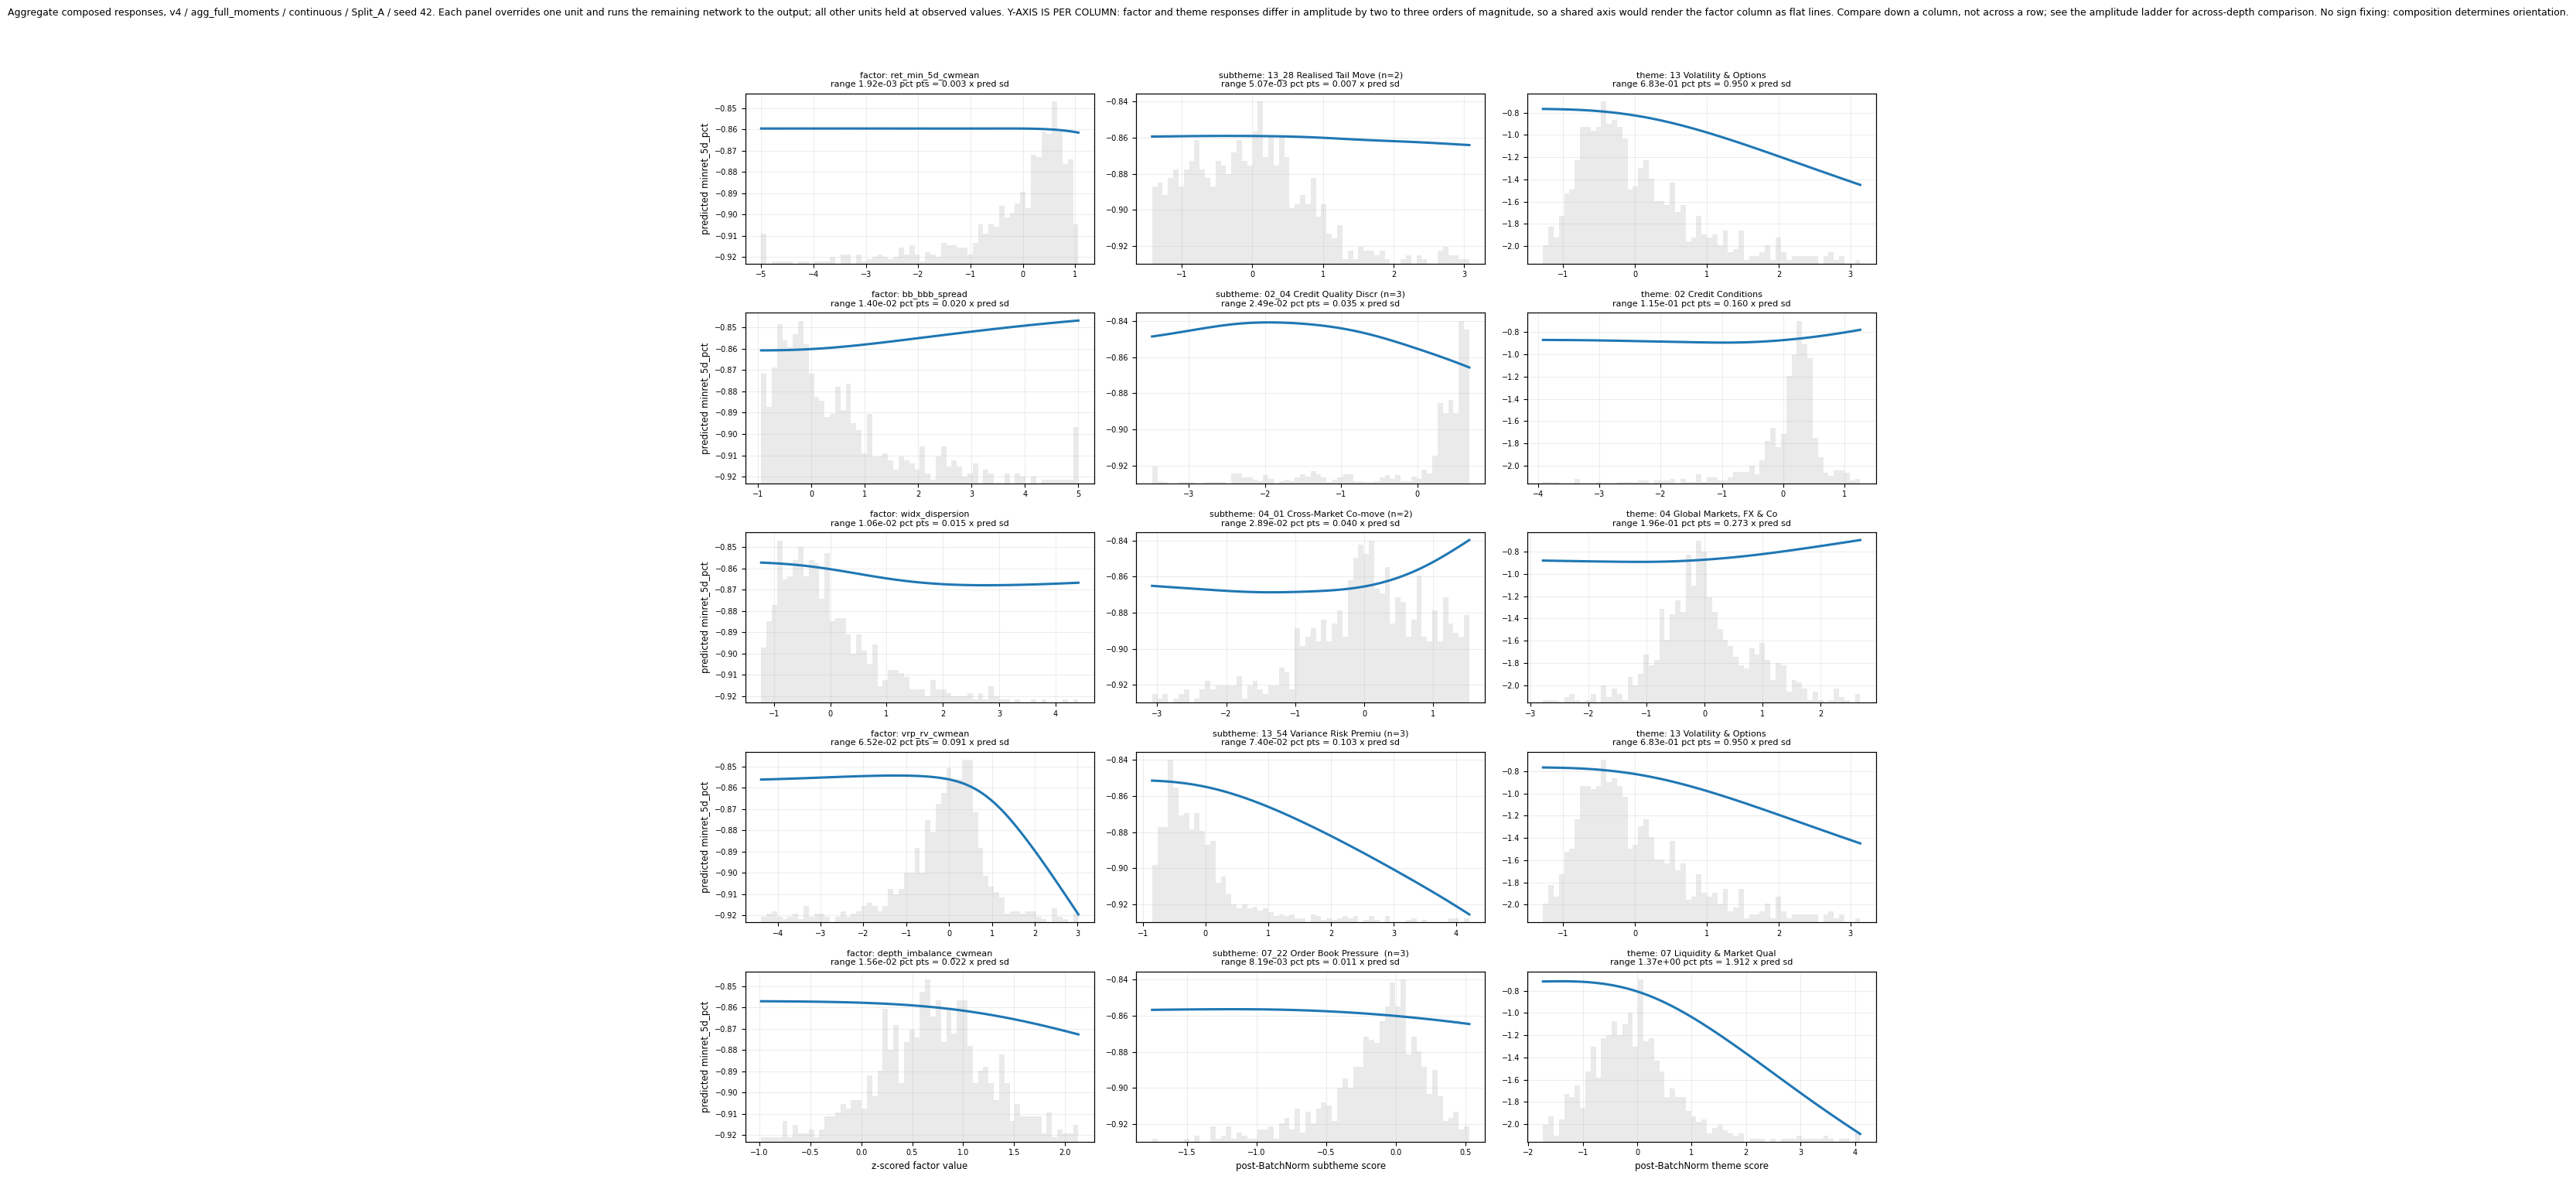


NARRATIVE CHECKS
                factor                               theme  dead  spline_pruned  feat_range  sub_range  th_range  monotone_rho  corr_with_theme_score  shape_vs_subtheme
     ret_min_5d_cwmean             13 Volatility & Options False          False     +0.0019    +0.0051   +0.6829       -0.6753                -0.8067            +0.8117
         bb_bbb_spread                02 Credit Conditions False          False     +0.0140    +0.0249   +0.1152       +1.0000                -0.3038            -0.5871
       widx_dispersion 04 Global Markets, FX & Commodities False          False     +0.0106    +0.0289   +0.1964       -0.8483                -0.3692            -0.4091
         vrp_rv_cwmean             13 Volatility & Options False          False     +0.0652    +0.0740   +0.6829       -0.6591                -0.0626            +0.6591
depth_imbalance_cwmean       07 Liquidity & Market Quality False          False     +0.0156    +0.0082   +1.3738       -1.0000           

In [5]:
# %% [markdown]
# # REPLACEMENT FOR PARTS 4 AND 5
#
# WHY THE FIRST VERSION LOOKED FLAT
# ---------------------------------
# The computation was correct. The figure was not. Panel ranges spanned
# 1.9e-03 (ret_min_5d at factor depth) to 1.37e+00 (Liquidity at theme depth),
# a factor of roughly 700, and sharey=True put all fifteen panels on the scale
# set by the largest. A curve moving 0.0019 occupies 0.14% of a 1.4-wide axis
# and is indistinguishable from a straight line.
#
# Two changes:
#   1. sharey="col". Each column now autoscales. Comparison DOWN a column
#      (across factors at the same depth) stays valid, which is the comparison
#      that matters. Comparison ACROSS a row no longer works visually, so the
#      amplitude ladder in Part 5b carries it numerically instead.
#   2. Every panel prints its range in output units AND as a multiple of the
#      model's own prediction standard deviation, so "small" has a referent.
#
# THE FLATNESS IS ALSO A RESULT
# -----------------------------
# Overriding one factor across its full observed range moves the prediction by
# 0.002 to 0.065 pct points. Overriding its theme score moves it by 0.12 to
# 1.37. That ordering is Section 7.5 in output units: there is nothing for a
# layer-0 spline to learn, and the model's usable variation lives at the theme
# layer where grouping has amplified reliability.

# %%
# =====================================================================
# PART 4 (corrected). Per-column y-axis
# =====================================================================

pred_sd = float(yhat_obs.std())
print(f"Model prediction sd on {PART}: {pred_sd:.4f} pct points")
print("Panel ranges below are quoted both absolutely and as a fraction of it.\n")

n = len(resolved)
fig, axes = plt.subplots(n, 3, figsize=(15.5, 3.1 * n),
                         sharey="col", squeeze=False)

COL_LABEL = ["factor", "subtheme", "theme"]
XLAB = ["z-scored factor value",
        "post-BatchNorm subtheme score",
        "post-BatchNorm theme score"]

for i, r in enumerate(resolved):
    triples = [
        (r["g_feat"], r["y_feat"], r["x_feat"], r["factor"][:30]),
        (r["g_sub"], r["y_sub"], r["x_sub"],
         f"{r['subtheme'][:26]} (n={r['n_in_subtheme']})"),
        (r["g_th"], r["y_th"], r["x_th"], r["theme"][:26]),
    ]
    for j, (gx, gy, obs, title) in enumerate(triples):
        ax = axes[i][j]
        if gx is None or gy is None:
            ax.text(.5, .5, "degenerate input", ha="center", va="center",
                    transform=ax.transAxes, fontsize=8)
            ax.set_xticks([]); ax.set_yticks([])
            continue

        tw = ax.twinx()
        tw.hist(obs[np.isfinite(obs)], bins=60, range=(gx[0], gx[-1]),
                color="grey", alpha=0.16)
        tw.set_yticks([])
        ax.set_zorder(tw.get_zorder() + 1)
        ax.patch.set_visible(False)

        rng = float(np.nanmax(gy) - np.nanmin(gy))
        frac = rng / pred_sd if pred_sd > 0 else np.nan
        flat = rng < DEAD_RANGE_THRESH
        ax.plot(gx, gy, lw=2.2, color="tab:red" if flat else "tab:blue")

        tag = ""
        if j == 0 and r["dead"]:
            tag = "  [DEAD]"
        elif j == 0 and r["pruned"]:
            tag = "  [spline pruned]"
        ax.set_title(f"{COL_LABEL[j]}: {title}{tag}\n"
                     f"range {rng:.2e} pct pts = {frac:.3f} x pred sd",
                     fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.22)
        if i == n - 1:
            ax.set_xlabel(XLAB[j], fontsize=8.5)
    axes[i][0].set_ylabel("predicted minret_5d_pct", fontsize=8.5)

fig.suptitle(
    f"Aggregate composed responses, v4 / {DATASET} / {TARGET} / {SPLIT} / seed {SEED}. "
    "Each panel overrides one unit and runs the remaining network to the output; "
    "all other units held at observed values. Y-AXIS IS PER COLUMN: factor and "
    "theme responses differ in amplitude by two to three orders of magnitude, so a "
    "shared axis would render the factor column as flat lines. Compare down a "
    "column, not across a row; see the amplitude ladder for across-depth "
    "comparison. No sign fixing: composition determines orientation.",
    fontsize=9,
)
fig.tight_layout(rect=[0, 0, 1, 1 - 0.075 * (3.0 / n)])
fig.savefig(FIG_DIR / "figF_aggregate_splines_five_factors.png",
            dpi=300, bbox_inches="tight")
plt.show()


# %%
# =====================================================================
# PART 5a. Narrative checks (unchanged logic, retained)
# =====================================================================

print("\n" + "=" * 78)
print("NARRATIVE CHECKS")
print("=" * 78)

rows = []
for r in resolved:
    if r["y_feat"] is None:
        continue
    yf, gf = r["y_feat"], r["g_feat"]
    rec = {
        "factor": r["factor"], "theme": r["theme"],
        "dead": r["dead"], "spline_pruned": r["pruned"],
        "feat_range": float(yf.max() - yf.min()),
        "sub_range": float(r["y_sub"].max() - r["y_sub"].min())
                     if r["y_sub"] is not None else np.nan,
        "th_range": float(r["y_th"].max() - r["y_th"].min())
                    if r["y_th"] is not None else np.nan,
        "monotone_rho": float(spearmanr(gf, yf).statistic),
        "corr_with_theme_score": float(np.corrcoef(r["x_feat"], r["x_th"])[0, 1]),
    }
    if r["y_sub"] is not None and len(r["y_sub"]) == len(yf):
        rec["shape_vs_subtheme"] = float(spearmanr(yf, r["y_sub"]).statistic)
    rows.append(rec)

chk = pd.DataFrame(rows)
chk.to_csv(TABLE_DIR / "aggregate_spline_narrative_checks.csv", index=False)
print(chk.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))


# %%
# =====================================================================
# PART 5b. THE AMPLITUDE LADDER
# =====================================================================
# This is the across-depth comparison the per-column axis gave up, and it is
# the quantity worth reporting. It answers: how much of the model's usable
# variation is reachable by intervening at each depth?

print("\n" + "=" * 78)
print("AMPLITUDE LADDER: output movement by intervention depth")
print("=" * 78)

lad = chk.copy()
lad["feat_x_sd"] = lad["feat_range"] / pred_sd
lad["sub_x_sd"] = lad["sub_range"] / pred_sd
lad["th_x_sd"] = lad["th_range"] / pred_sd
lad["theme_over_factor"] = lad["th_range"] / lad["feat_range"]
lad["sub_over_factor"] = lad["sub_range"] / lad["feat_range"]

show = lad[["factor", "feat_range", "sub_range", "th_range",
            "feat_x_sd", "th_x_sd", "sub_over_factor", "theme_over_factor"]]
print(show.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
lad.to_csv(TABLE_DIR / "aggregate_spline_amplitude_ladder.csv", index=False)

print(f"\nMedian amplification, factor -> subtheme: "
      f"{lad['sub_over_factor'].median():.1f}x")
print(f"Median amplification, factor -> theme:    "
      f"{lad['theme_over_factor'].median():.1f}x")
print(f"Prediction sd for reference: {pred_sd:.4f} pct points")

print("""
HOW TO READ THIS, AND WHAT IT DOES AND DOES NOT SHOW

  It does show that intervening at the theme layer moves the prediction one to
  three orders of magnitude more than intervening on a single factor. Given
  each theme aggregates dozens of factors, some of that gap is simple
  arithmetic: one factor is a small share of its theme, so a full-range swing
  in one input cannot move a theme score far. The gap is NOT by itself
  evidence that layer 0 is broken.

  It does show, when read against the near-monotone factor curves and the
  layer-0 departure statistics from notebook 17 Part 4, that layer 0 is
  contributing a direction rather than a shape. Both facts point the same way
  and neither is sufficient alone.

  It does NOT license a per-factor importance ranking. Partial dependence
  holds other factors at observed values, so correlated factors share credit
  and a small feat_range does not mean a factor is uninformative. Use the full
  sweep in v4_factor_swing_FULL.csv for ranking, not this table.
""")

# ── the honest reading of the factor column ──
live = chk[~chk["dead"]]
if len(live):
    mono = live[live["monotone_rho"].abs() > 0.98]
    print(f"{len(mono)} of {len(live)} live factors are monotone (|rho| > 0.98).")
    if len(mono) == len(live):
        print("""
  Every live factor is monotone. At G=3 with a near-pure SiLU base this is the
  expected outcome and it is the confirmation of Section 7.5, not a failure:
  there is no learnable curvature at layer 0, so the model found a direction
  and no shape. Do NOT caption these panels as thresholds, regime flips, or
  gamma-flip crossings. Those readings require curvature the model did not
  find, and an examiner reading the range annotations will see that.

  The threshold and regime-flip narratives for vrp_rv and widx_dispersion
  specifically cannot be supported from this figure. Either drop them or state
  them as motivation for factor construction rather than as findings.
""")
    else:
        keep = live[live["monotone_rho"].abs() <= 0.98]["factor"].tolist()
        print(f"\n  Factors carrying real curvature, worth showing: {keep}")
        print("  The monotone ones can be cut from the figure without loss.")

print(f"Figure: {FIG_DIR / 'figF_aggregate_splines_five_factors.png'}")
print(f"Tables: {TABLE_DIR}")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: Tesla T4 (CUDA)
Device: cuda
Verification PASS: recomputed R2 -0.0294 vs saved -0.0294

FACTOR RESOLUTION
  ret_min_5d         -> ret_min_5d_cwmean                col   476  sub[293] 13_28 Realised Tail Move  theme[12] 13 Volatility & Options
  bb_bbb_spread      -> bb_bbb_spread                    col   705  sub[44] 02_04 Credit Quality Discrim  theme[1] 02 Credit Conditions
  widx_dispersion    -> widx_dispersion                  col   814  sub[70] 04_01 Cross-Market Co-moveme  theme[3] 04 Global Markets, FX & 
  vrp_rv             -> vrp_rv_cwmean                    col   140  sub[319] 13_54 Variance Risk Premium  theme[12] 13 Volatility & Options
  depth_imbalance    -> depth_imbalance_cwmean           col   300  s

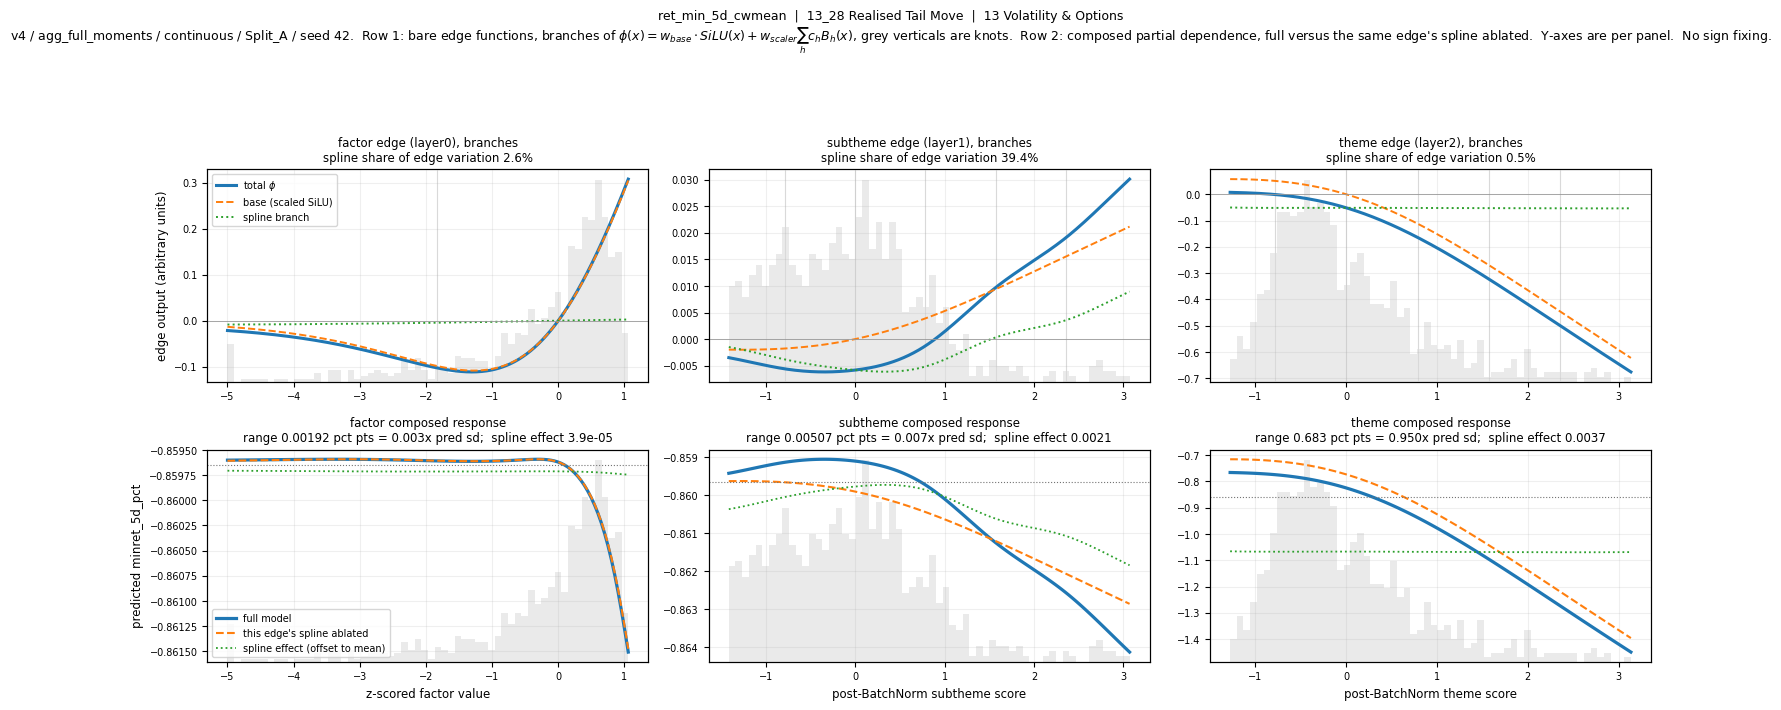

  saved figG_ret_min_5d_cwmean.png


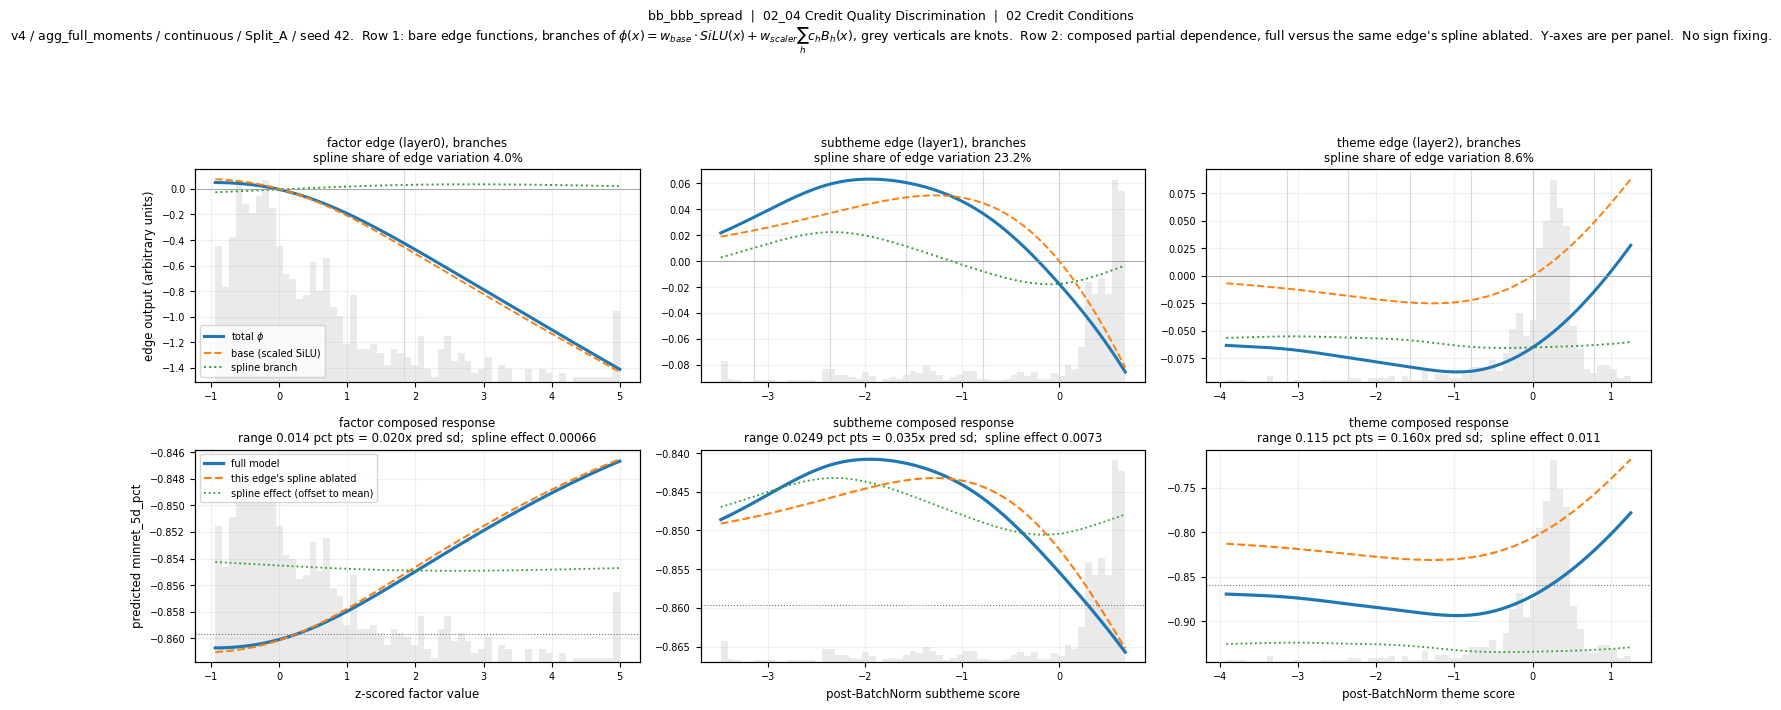

  saved figG_bb_bbb_spread.png


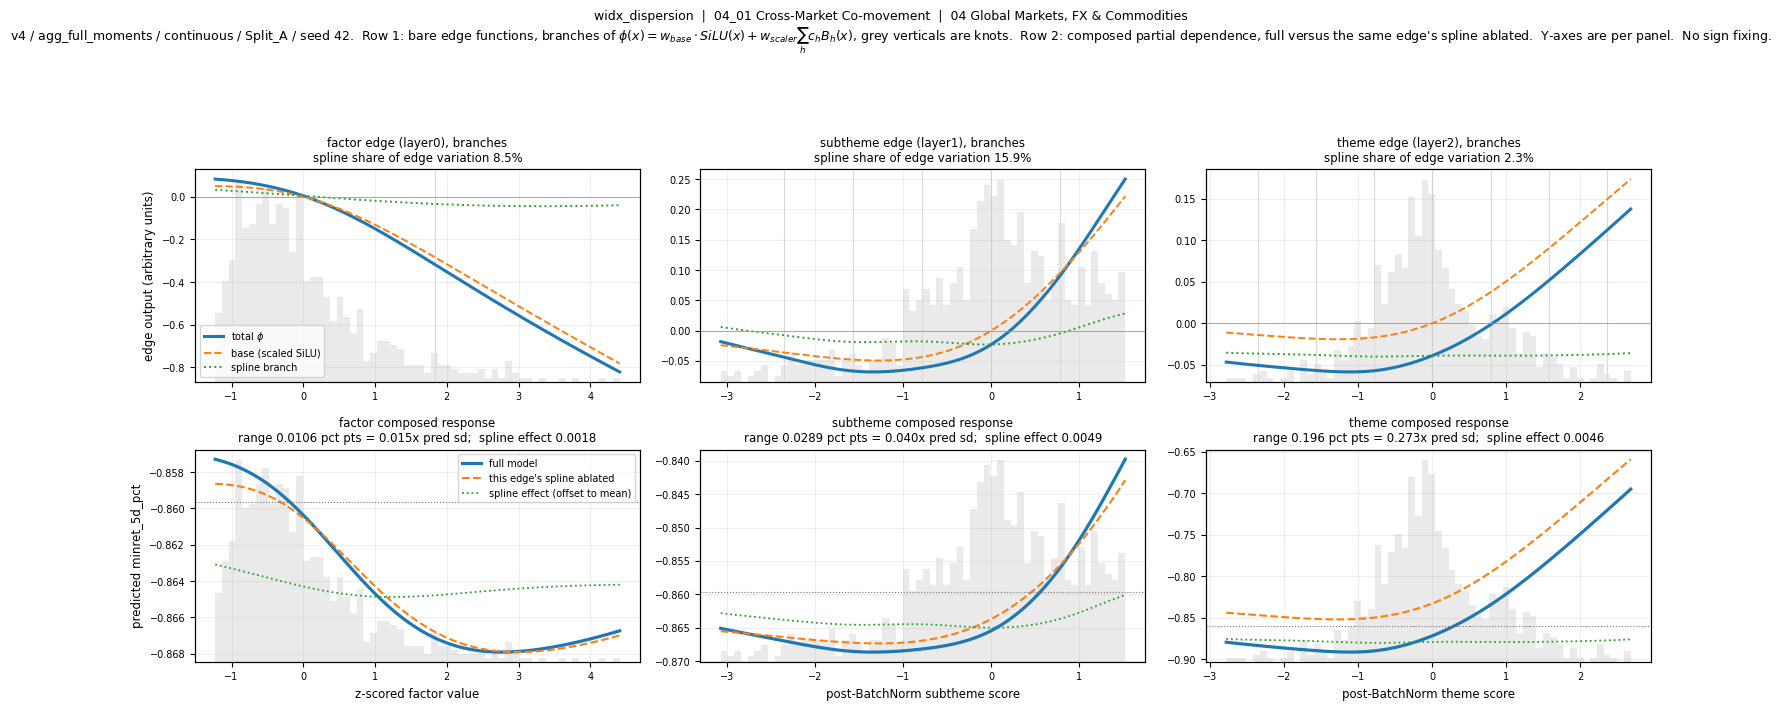

  saved figG_widx_dispersion.png


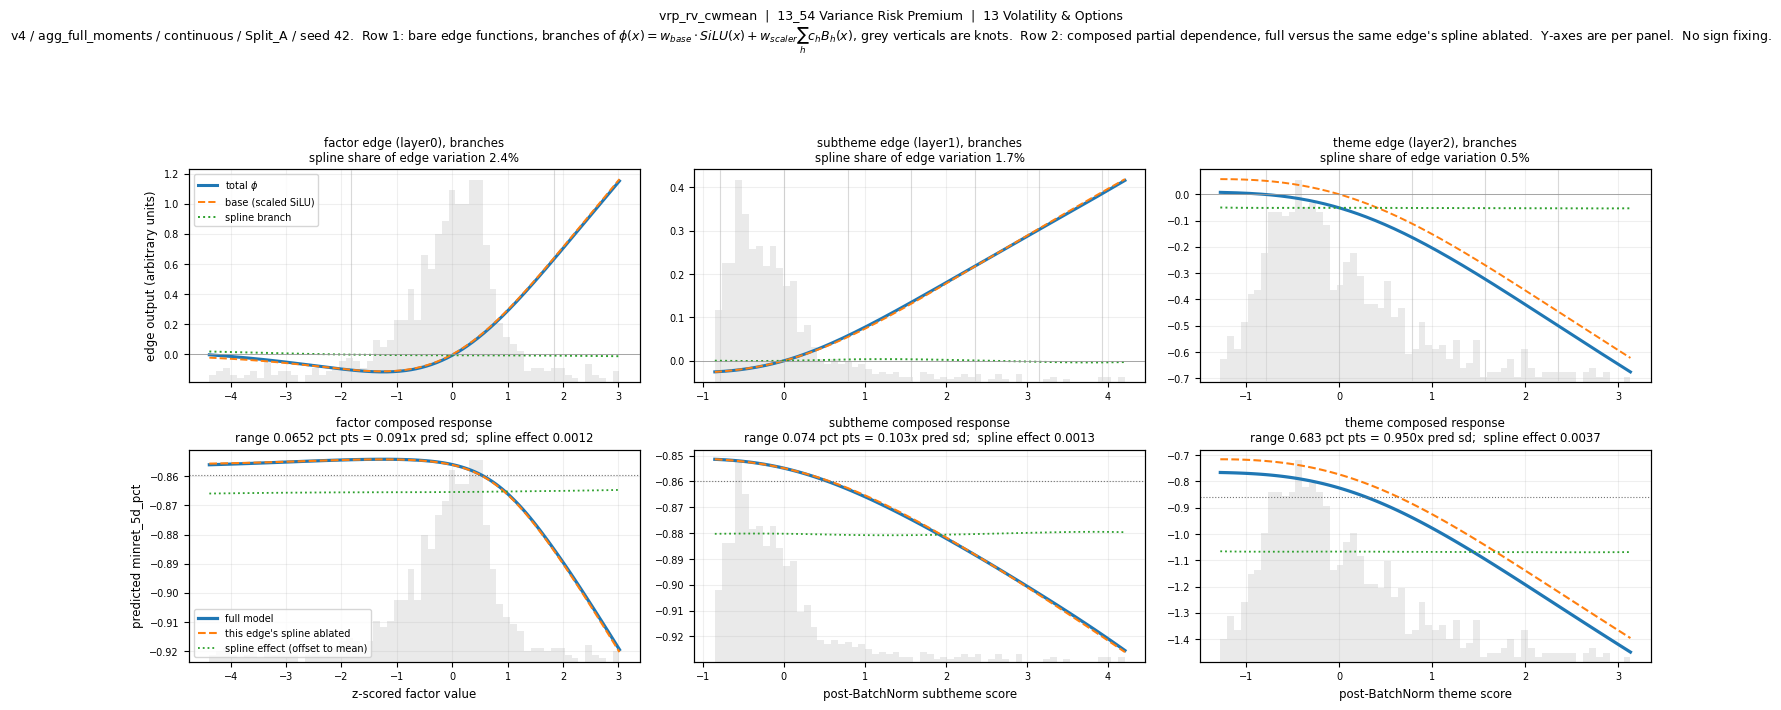

  saved figG_vrp_rv_cwmean.png


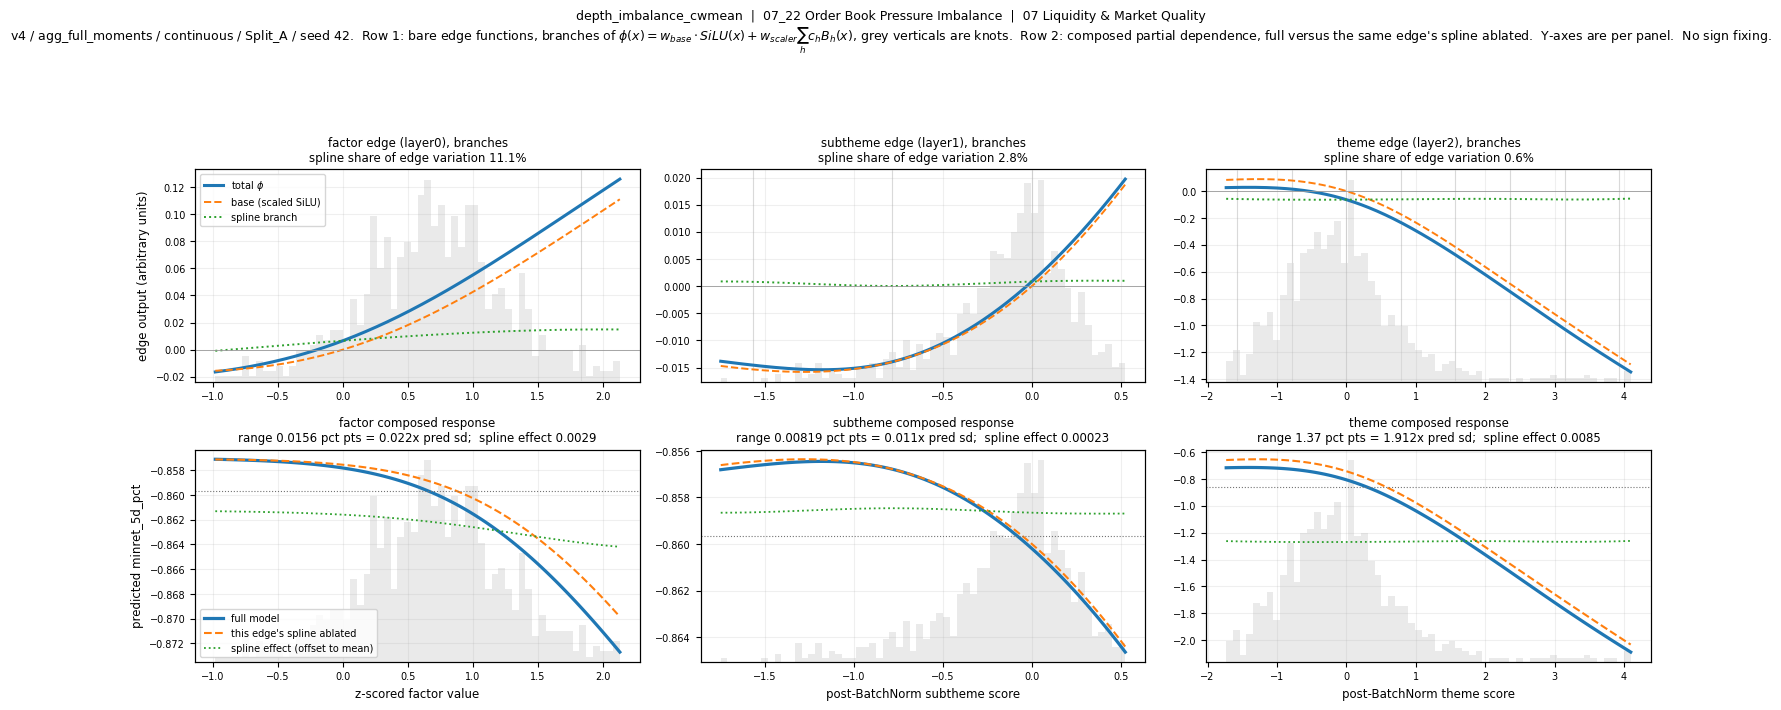

  saved figG_depth_imbalance_cwmean.png

AMPLITUDE LADDER AND SPLINE SHARE
                factor                               theme  dead  spline_pruned  feat_rng  sub_rng  th_rng  spl_share_factor  spl_share_subtheme  spl_share_theme  spl_effect_factor  monotone_rho  th_over_feat
     ret_min_5d_cwmean             13 Volatility & Options False          False  0.001917 0.005073  0.6829           0.02583              0.3943         0.005364           3.85e-05       -0.6753         356.2
         bb_bbb_spread                02 Credit Conditions False          False   0.01403  0.02492  0.1152           0.03959              0.2323           0.0856          0.0006565             1         8.212
       widx_dispersion 04 Global Markets, FX & Commodities False          False   0.01063  0.02891  0.1964            0.0848              0.1591          0.02347           0.001788       -0.8483         18.48
         vrp_rv_cwmean             13 Volatility & Options False          False   0.06524

In [6]:
# %% [markdown]
# # Per-factor aggregate response, with SiLU and spline branches shown
#
# ONE FIGURE PER FACTOR, TWO ROWS x THREE DEPTHS
# ----------------------------------------------
#   Row 1, BARE EDGE FUNCTIONS, in that edge's own output units.
#     The three branches of phi(x) = w_base . SiLU(x) + w_scaler . sum_h c_h B_h(x)
#     plotted separately: base (scaled SiLU), spline, and their total. This is
#     the same object as figA/figB in notebook 17.
#
#   Row 2, COMPOSED RESPONSE, in predicted minret_5d_pct.
#     Partial dependence at that depth, run through the remaining network to the
#     output. Three curves: the full model, the model with THIS EDGE's spline
#     branch ablated (so only its SiLU base propagates), and the difference,
#     which is what the spline is worth at the output.
#
# WHY ROW 2 NEEDS THE ABLATION RATHER THAN AN ALGEBRAIC SPLIT
# ----------------------------------------------------------
# A composed response has no base/spline decomposition, because everything
# downstream (BatchNorm, the clamp, two more spline layers) is nonlinear in the
# edge's output. Zeroing spline_scaler for one edge and re-running is the only
# honest way to attribute output movement to that edge's spline branch. The
# difference curve is therefore an ablation effect, not an additive component,
# and it will not in general equal the row-1 spline curve pushed through a
# constant.
#
# Y-AXES ARE PER PANEL. Factor-depth and theme-depth responses differ by two to
# three orders of magnitude; a shared axis renders the factor column flat. The
# amplitude ladder at the end carries the across-depth comparison numerically.
#
# CONVENTIONS FROM NOTEBOOK 17 (each was a prior error)
#   - checkpoint is sparse_kan_{ds}_{tt}_{sp}.pt for EVERY arm, v4 included
#   - built via from_taxonomy with grid_size_0 / grid_size_12
#   - bn eps set BEFORE load_state_dict (not in state_dict)
#   - forward clamps to [-5, 5] after each BatchNorm
#   - continuous target is minret_test, NOT y_test
#   - no sign fixing: composition determines orientation

# %%
!pip install -q git+https://github.com/Blealtan/efficient-kan.git optuna
from google.colab import drive
drive.mount("/content/drive")
import sys
sys.path.insert(0, "/content/drive/MyDrive/Thesis/Code")

# %%
import contextlib
import io
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from data_utils import load_split, get_device, load_theme_assignment
from evaluation import load_predictions
import sparse_kan_v4 as skan_v4

device = get_device()
print(f"Device: {device}")

SPLITS_DIR = Path("/content/drive/MyDrive/Thesis/Data/Stage_5_Model_Ready/04_splits")
THEMES_DIR = Path("/content/drive/MyDrive/Thesis/Data/Stage_5_Model_Ready/05_themes")
BASE = Path("/content/drive/MyDrive/Thesis/Data/Results/Dense_vs_Sparse_KAN_v2")
V4_DIR = BASE / "sparse_kan_v4"
OUT_DIR = BASE / "v4_analysis"
FIG_DIR = OUT_DIR / "figures" / "per_factor"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

FACTOR_QUERIES = [
    "ret_min_5d",        # Realised Tail Move
    "bb_bbb_spread",     # Credit Quality Discrimination
    "widx_dispersion",   # Cross-Market Co-movement
    "vrp_rv",            # Variance Risk Premium
    "depth_imbalance",   # Order Book Pressure Imbalance
]

DATASET = "agg_full_moments"
TARGET = "continuous"
SPLIT = "Split_A"
SEED = 42
PART = "train"

SPLINE_ORDER = 3
GRID_RANGE = [-5.5, 5.5]
V4_GRID_KWARGS = {"grid_size_0": 3, "grid_size_12": 14}
V4_EPS = 1e-5

N_SWEEP = 120
N_EDGE = 400          # resolution for the bare edge curves (cheap)
PCT = (1, 99)
MAX_PD_ROWS = 800
DEAD_RANGE_THRESH = 1e-4


def to_np(t):
    return t.detach().cpu().numpy()


# %%
# =====================================================================
# Loading and forward, matching notebook 17
# =====================================================================

def load_v4(dataset, target_type, split_name, seed):
    p = (V4_DIR / f"seed_{seed}" / "checkpoints"
         / f"sparse_kan_{dataset}_{target_type}_{split_name}.pt")
    if not p.exists():
        avail = sorted((V4_DIR / f"seed_{seed}" / "checkpoints").glob("*.pt"))
        raise FileNotFoundError(f"No checkpoint at {p}\n"
                                f"Available: {[c.name for c in avail[:12]]}")
    data = load_split(split_name, dataset, SPLITS_DIR)
    tax = load_theme_assignment(dataset, THEMES_DIR)
    m = skan_v4.SparseKAN.from_taxonomy(
        tax, data["feature_cols"],
        spline_order=SPLINE_ORDER, grid_range=GRID_RANGE, **V4_GRID_KWARGS,
    ).to(device)
    m.bn1.eps = V4_EPS
    m.bn2.eps = V4_EPS
    ckpt = torch.load(p, map_location=device, weights_only=False)
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()
    with contextlib.redirect_stdout(io.StringIO()):
        assert m.verify_masking(), "masking broken on load"
    for prm in m.parameters():
        prm.requires_grad_(False)
    return m, data, ckpt


@torch.no_grad()
def fwd_all(m, X):
    x0 = torch.nan_to_num(X, nan=0.0)
    z1 = torch.clamp(m.bn1(m.layer0(x0)), -5.0, 5.0)
    z2 = torch.clamp(m.bn2(m.layer1(z1)), -5.0, 5.0)
    return z1, z2, m.layer2(z2).squeeze(-1)


@torch.no_grad()
def from_z1(m, z1):
    z2 = torch.clamp(m.bn2(m.layer1(z1)), -5.0, 5.0)
    return m.layer2(z2).squeeze(-1)


@torch.no_grad()
def from_z2(m, z2):
    return m.layer2(z2).squeeze(-1)


@torch.no_grad()
def theme_contributions(m, z2):
    B = m.layer2.b_splines(z2)
    out = torch.zeros(len(z2), m.n_themes, device=z2.device)
    for t in range(m.n_themes):
        out[:, t] = (m.layer2.base_weight[0, t] * F.silu(z2[:, t])
                     + B[:, t, :] @ m.layer2.scaled_spline_weight[0, t, :])
    return out


def r2_score(y_true, y_pred):
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan")


@torch.no_grad()
def edge_curve(layer, p, q, z):
    """Bare edge function and its two branches, in edge output units."""
    x = torch.zeros(len(z), layer.in_features, device=z.device)
    x[:, p] = z
    spl = layer.b_splines(x)[:, p, :] @ layer.scaled_spline_weight[q, p, :]
    base = layer.base_weight[q, p] * F.silu(z)
    return base + spl, base, spl


@contextlib.contextmanager
def ablate_edge_spline(layer, q, p):
    """Zero ONE edge's spline branch. Base/SiLU untouched. Restores on exit."""
    saved = layer.spline_scaler.data[q, p].clone()
    layer.spline_scaler.data[q, p] = 0.0
    try:
        yield
    finally:
        layer.spline_scaler.data[q, p] = saved


m, data, ckpt = load_v4(DATASET, TARGET, SPLIT, SEED)

Xte = torch.tensor(np.nan_to_num(data["X_test"]), dtype=torch.float32, device=device)
yte = torch.tensor(data["minret_test"], dtype=torch.float32, device=device)
recomputed = r2_score(yte, fwd_all(m, Xte)[2])
saved = float(load_predictions(model_name=f"sparse_kan_{DATASET}", split_name=SPLIT,
                               target_type=TARGET, part="test",
                               results_dir=V4_DIR / f"seed_{SEED}")["metrics"]["r2"])
assert abs(recomputed - saved) < 0.01, (
    f"Forward does not reproduce saved metrics ({recomputed:+.4f} vs {saved:+.4f})."
)
print(f"Verification PASS: recomputed R2 {recomputed:+.4f} vs saved {saved:+.4f}")


# %%
# =====================================================================
# Resolve factors, then liveness pre-check
# =====================================================================

feature_names = list(m._feature_names)


def resolve(query):
    exact = [f for f in feature_names if f.lower() == query.lower()]
    if exact:
        return exact[0], exact
    subs = [f for f in feature_names if query.lower() in f.lower()]
    if not subs:
        return None, []
    pref = [f for f in subs if f.lower().endswith(("cwmean", "_mean"))] or subs
    return pref[0], subs


resolved = []
print("\n" + "=" * 78)
print("FACTOR RESOLUTION")
print("=" * 78)
for q in FACTOR_QUERIES:
    chosen, all_m = resolve(q)
    if chosen is None:
        stem = q.split("_")[0]
        print(f"  {q:<18} NOT FOUND. Closest: "
              f"{[f for f in feature_names if stem in f.lower()][:8]}")
        continue
    col = feature_names.index(chosen)
    s_idx = int(m.layer0.mask[:, col].nonzero()[0])
    t_idx = int(m.layer1.mask[:, s_idx].nonzero()[0])
    resolved.append({"query": q, "factor": chosen, "col": col,
                     "s_idx": s_idx, "t_idx": t_idx,
                     "subtheme": m._subtheme_names[s_idx],
                     "theme": m._theme_names[t_idx],
                     "n_in_subtheme": int(m.layer0.mask[s_idx].sum())})
    print(f"  {q:<18} -> {chosen:<32} col {col:>5}  "
          f"sub[{s_idx}] {m._subtheme_names[s_idx][:28]}  "
          f"theme[{t_idx}] {m._theme_names[t_idx][:24]}")

if not resolved:
    raise SystemExit("Nothing resolved. Fix FACTOR_QUERIES.")

X = torch.tensor(np.nan_to_num(data[f"X_{PART}"]), dtype=torch.float32, device=device)
if len(X) > MAX_PD_ROWS:
    X = X[np.linspace(0, len(X) - 1, MAX_PD_ROWS).astype(int)]
z1_obs, z2_obs, yhat_obs = fwd_all(m, X)
mean_pred = float(yhat_obs.mean())
pred_sd = float(yhat_obs.std())
ledger_err = float((theme_contributions(m, z2_obs).sum(1) - yhat_obs).abs().max())
print(f"\nPD rows {len(X)} from {PART};  mean pred {mean_pred:+.4f};  "
      f"pred sd {pred_sd:.4f};  ledger exact to {ledger_err:.1e}")

l0_med = float(m.layer0.spline_scaler.data.abs()[m.layer0.mask.bool()].median())

print("\n" + "=" * 78)
print("LIVENESS PRE-CHECK (before any sweeping)")
print("=" * 78)
print(f"{'factor':<26} {'|base|':>9} {'|scaler|':>10} {'edge sd':>9} "
      f"{'probe rng':>10}  verdict")
print("-" * 78)
for r in resolved:
    col, s_idx = r["col"], r["s_idx"]
    with torch.no_grad():
        base_w = float(m.layer0.base_weight[s_idx, col].abs())
        scaler = float(m.layer0.spline_scaler.data[s_idx, col].abs())
        xcol = X[:, col]
        tot, _, _ = edge_curve(m.layer0, col, s_idx, xcol)
        edge_sd = float(tot.std())
        xn = to_np(xcol)
        lo, hi = np.percentile(xn[np.isfinite(xn)], PCT)
        probe = []
        for v in (lo, hi):
            Xv = X.clone(); Xv[:, col] = float(v)
            probe.append(fwd_all(m, Xv)[2].mean().item())
        probe_rng = abs(probe[1] - probe[0])
    pruned = scaler < 0.01 * l0_med
    dead = (edge_sd < 1e-9) or (probe_rng < DEAD_RANGE_THRESH)
    r.update(base_w=base_w, scaler=scaler, edge_sd=edge_sd,
             probe_rng=probe_rng, pruned=pruned, dead=dead)
    print(f"{r['factor'][:26]:<26} {base_w:9.2e} {scaler:10.2e} {edge_sd:9.2e} "
          f"{probe_rng:10.2e}  "
          f"{'DEAD' if dead else ('live, spline pruned' if pruned else 'live')}")
print("-" * 78)
print("'spline pruned' means L1 removed the spline branch but the SiLU base "
      "still propagates, so row 1 will show a flat green curve and row 2's "
      "ablation difference will be zero by construction.")
pd.DataFrame(resolved).to_csv(TABLE_DIR / "per_factor_liveness.csv", index=False)


# %%
# =====================================================================
# Sweeps: composed response, full and with this edge's spline ablated
# =====================================================================

def grid_over(v):
    v = v[np.isfinite(v)]
    lo, hi = np.percentile(v, PCT)
    return None if hi - lo < 1e-12 else np.linspace(lo, hi, N_SWEEP)


@torch.no_grad()
def pd_feature(col, grid):
    out = []
    for val in grid:
        Xv = X.clone(); Xv[:, col] = float(val)
        out.append(fwd_all(m, Xv)[2].mean().item())
    return np.array(out)


@torch.no_grad()
def pd_subtheme(s_idx, grid):
    out = []
    for val in grid:
        z = z1_obs.clone(); z[:, s_idx] = float(val)
        out.append(from_z1(m, z).mean().item())
    return np.array(out)


@torch.no_grad()
def pd_theme(t_idx, grid):
    out = []
    for val in grid:
        z = z2_obs.clone(); z[:, t_idx] = float(val)
        out.append(from_z2(m, z).mean().item())
    return np.array(out)


print("\n" + "=" * 78)
print("SWEEPING (full and spline-ablated, per depth)")
print("=" * 78)
t0 = time.time()
for r in resolved:
    col, s_idx, t_idx = r["col"], r["s_idx"], r["t_idx"]
    r["x_feat"] = to_np(X[:, col])
    r["x_sub"] = to_np(z1_obs[:, s_idx])
    r["x_th"] = to_np(z2_obs[:, t_idx])
    r["g_feat"] = grid_over(r["x_feat"])
    r["g_sub"] = grid_over(r["x_sub"])
    r["g_th"] = grid_over(r["x_th"])

    # full
    r["y_feat"] = pd_feature(col, r["g_feat"]) if r["g_feat"] is not None else None
    r["y_sub"] = pd_subtheme(s_idx, r["g_sub"]) if r["g_sub"] is not None else None
    r["y_th"] = pd_theme(t_idx, r["g_th"]) if r["g_th"] is not None else None

    # spline-ablated, one edge at a time
    if r["g_feat"] is not None:
        with ablate_edge_spline(m.layer0, s_idx, col):
            r["y_feat_nospl"] = pd_feature(col, r["g_feat"])
    if r["g_sub"] is not None:
        with ablate_edge_spline(m.layer1, t_idx, s_idx):
            r["y_sub_nospl"] = pd_subtheme(s_idx, r["g_sub"])
    if r["g_th"] is not None:
        with ablate_edge_spline(m.layer2, 0, t_idx):
            r["y_th_nospl"] = pd_theme(t_idx, r["g_th"])

    print(f"  {r['factor'][:34]:<34} {time.time()-t0:6.0f}s")


# %%
# =====================================================================
# One figure per factor: 2 rows x 3 depths
# =====================================================================

DEPTHS = [
    ("factor", "layer0", "z-scored factor value"),
    ("subtheme", "layer1", "post-BatchNorm subtheme score"),
    ("theme", "layer2", "post-BatchNorm theme score"),
]

for r in resolved:
    specs = [
        # layer, p, q, grid, obs, y_full, y_nospl, title
        (m.layer0, r["col"], r["s_idx"], r["g_feat"], r["x_feat"],
         r.get("y_feat"), r.get("y_feat_nospl"),
         f"{r['factor'][:34]}"),
        (m.layer1, r["s_idx"], r["t_idx"], r["g_sub"], r["x_sub"],
         r.get("y_sub"), r.get("y_sub_nospl"),
         f"{r['subtheme'][:30]} (n={r['n_in_subtheme']})"),
        (m.layer2, r["t_idx"], 0, r["g_th"], r["x_th"],
         r.get("y_th"), r.get("y_th_nospl"),
         f"{r['theme'][:30]}"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(15.5, 7.2), squeeze=False)

    for j, (layer, p, q, gx, obs, y_full, y_nospl, title) in enumerate(specs):
        ax_edge, ax_comp = axes[0][j], axes[1][j]
        depth_name, layer_name, xlab = DEPTHS[j]

        if gx is None:
            for ax in (ax_edge, ax_comp):
                ax.text(.5, .5, "degenerate input", ha="center", va="center",
                        transform=ax.transAxes, fontsize=8)
                ax.set_xticks([]); ax.set_yticks([])
            continue

        # ── ROW 1: bare edge, three branches ──
        z = torch.linspace(float(gx[0]), float(gx[-1]), N_EDGE, device=device)
        tot, base, spl = edge_curve(layer, p, q, z)
        zc, totc, basec, splc = to_np(z), to_np(tot), to_np(base), to_np(spl)

        tw = ax_edge.twinx()
        tw.hist(obs[np.isfinite(obs)], bins=60, range=(gx[0], gx[-1]),
                color="grey", alpha=0.16)
        tw.set_yticks([])
        ax_edge.set_zorder(tw.get_zorder() + 1)
        ax_edge.patch.set_visible(False)

        ax_edge.plot(zc, totc, lw=2.2, color="tab:blue", label=r"total $\phi$")
        ax_edge.plot(zc, basec, lw=1.4, color="tab:orange", ls="--",
                     label="base (scaled SiLU)")
        ax_edge.plot(zc, splc, lw=1.4, color="tab:green", ls=":",
                     label="spline branch")
        k = layer.spline_order
        for kn in to_np(layer.grid[p, k:-k]):
            if gx[0] <= kn <= gx[-1]:
                ax_edge.axvline(kn, color="0.85", lw=0.8, zorder=0)
        ax_edge.axhline(0, color="0.6", lw=0.6)

        spl_share = (float(np.ptp(splc)) /
                     max(float(np.ptp(basec)) + float(np.ptp(splc)), 1e-12))
        ax_edge.set_title(
            f"{depth_name} edge ({layer_name}), branches\n"
            f"spline share of edge variation {spl_share:.1%}", fontsize=8.5)
        ax_edge.tick_params(labelsize=7)
        ax_edge.grid(alpha=0.2)
        if j == 0:
            ax_edge.set_ylabel("edge output (arbitrary units)", fontsize=8.5)
            ax_edge.legend(fontsize=7, loc="best")

        # ── ROW 2: composed response, full vs spline-ablated ──
        tw2 = ax_comp.twinx()
        tw2.hist(obs[np.isfinite(obs)], bins=60, range=(gx[0], gx[-1]),
                 color="grey", alpha=0.16)
        tw2.set_yticks([])
        ax_comp.set_zorder(tw2.get_zorder() + 1)
        ax_comp.patch.set_visible(False)

        rng = float(np.ptp(y_full))
        flat = rng < DEAD_RANGE_THRESH
        ax_comp.plot(gx, y_full, lw=2.3,
                     color="tab:red" if flat else "tab:blue",
                     label="full model")
        if y_nospl is not None:
            ax_comp.plot(gx, y_nospl, lw=1.5, color="tab:orange", ls="--",
                         label="this edge's spline ablated")
            delta = y_full - y_nospl
            ax_comp.plot(gx, delta + np.nanmean(y_full), lw=1.3,
                         color="tab:green", ls=":",
                         label="spline effect (offset to mean)")
            d_rng = float(np.ptp(delta))
        else:
            d_rng = np.nan
        ax_comp.axhline(mean_pred, color="0.45", lw=0.8, ls=":")

        tag = ""
        if j == 0 and r["dead"]:
            tag = "  [DEAD]"
        elif j == 0 and r["pruned"]:
            tag = "  [spline pruned]"
        ax_comp.set_title(
            f"{depth_name} composed response{tag}\n"
            f"range {rng:.3g} pct pts = {rng/pred_sd:.3f}x pred sd;  "
            f"spline effect {d_rng:.2g}", fontsize=8.5)
        ax_comp.set_xlabel(xlab, fontsize=8.5)
        ax_comp.tick_params(labelsize=7)
        ax_comp.grid(alpha=0.2)
        if j == 0:
            ax_comp.set_ylabel("predicted minret_5d_pct", fontsize=8.5)
            ax_comp.legend(fontsize=7, loc="best")

        r[f"spl_share_{depth_name}"] = spl_share
        r[f"delta_rng_{depth_name}"] = d_rng

    fig.suptitle(
        f"{r['factor']}  |  {r['subtheme']}  |  {r['theme']}\n"
        f"v4 / {DATASET} / {TARGET} / {SPLIT} / seed {SEED}.  "
        "Row 1: bare edge functions, branches of "
        r"$\phi(x)=w_{base}\cdot SiLU(x)+w_{scaler}\sum_h c_h B_h(x)$, "
        "grey verticals are knots.  "
        "Row 2: composed partial dependence, full versus the same edge's spline "
        "ablated.  Y-axes are per panel.  No sign fixing.",
        fontsize=9)
    fig.tight_layout(rect=[0, 0, 1, 0.91])
    fname = FIG_DIR / f"figG_{r['factor']}.png"
    fig.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"  saved {fname.name}")


# %%
# =====================================================================
# Amplitude ladder and the honest reading
# =====================================================================

print("\n" + "=" * 78)
print("AMPLITUDE LADDER AND SPLINE SHARE")
print("=" * 78)

rows = []
for r in resolved:
    if r.get("y_feat") is None:
        continue
    rows.append({
        "factor": r["factor"], "theme": r["theme"],
        "dead": r["dead"], "spline_pruned": r["pruned"],
        "feat_rng": float(np.ptp(r["y_feat"])),
        "sub_rng": float(np.ptp(r["y_sub"])) if r.get("y_sub") is not None else np.nan,
        "th_rng": float(np.ptp(r["y_th"])) if r.get("y_th") is not None else np.nan,
        "spl_share_factor": r.get("spl_share_factor", np.nan),
        "spl_share_subtheme": r.get("spl_share_subtheme", np.nan),
        "spl_share_theme": r.get("spl_share_theme", np.nan),
        "spl_effect_factor": r.get("delta_rng_factor", np.nan),
        "monotone_rho": float(spearmanr(r["g_feat"], r["y_feat"]).statistic),
    })
lad = pd.DataFrame(rows)
lad["th_over_feat"] = lad["th_rng"] / lad["feat_rng"]
lad.to_csv(TABLE_DIR / "per_factor_amplitude_ladder.csv", index=False)
print(lad.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
print(f"\nPrediction sd: {pred_sd:.4f} pct points")
print(f"Median theme/factor amplitude ratio: {lad['th_over_feat'].median():.1f}x")
print(f"Median layer-0 spline share of edge variation: "
      f"{lad['spl_share_factor'].median():.1%}")

print("""
READING NOTES, INCLUDING WHAT THIS CANNOT SHOW

  spl_share_* is the spline branch's share of that EDGE's variation, computed
  on the plotted range. It is a property of the edge, not of the output. A high
  share on an edge whose composed response barely moves is not important.

  spl_effect_factor is the ablation effect at the OUTPUT, which is the number
  that matters. If it is orders of magnitude below feat_rng, the layer-0 spline
  is decorative: the SiLU base is carrying that factor's entire contribution.

  The theme/factor amplitude ratio has an innocent component. One factor is a
  small share of a theme aggregating dozens of factors, so arithmetic alone
  guarantees some gap. Do NOT present the ratio on its own as proof that layer
  0 is inert. The claim needs the monotonicity of the factor curves and the
  layer-0 departure statistics from notebook 17 Part 4 alongside it.

  Partial dependence holds correlated factors at observed values, so these
  ranges are not an importance ranking. Use v4_factor_swing_FULL.csv for that.
""")

live = lad[~lad["dead"]]
if len(live):
    mono = live[live["monotone_rho"].abs() > 0.98]
    print(f"{len(mono)} of {len(live)} live factors are monotone (|rho| > 0.98).")
    if len(mono) == len(live):
        print("""
  All live factors monotone. At G=3 over 6 basis functions with a near-pure
  SiLU base this is the expected outcome, and it is Section 7.5 confirmed in
  output units rather than a failure. Caption these as a direction found and
  no shape found. The threshold and regime-flip readings for vrp_rv and
  widx_dispersion are not supportable from this figure; keep them as
  motivation for factor construction, not as findings.
""")
    else:
        keep = live[live["monotone_rho"].abs() <= 0.98]["factor"].tolist()
        print(f"\n  Carrying real curvature, worth showing: {keep}")

print(f"Figures: {FIG_DIR}")
print(f"Tables:  {TABLE_DIR}")

In [4]:
import pandas as pd, numpy as np
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 60)

KAN  = "/content/drive/MyDrive/Thesis/Data/Results/Dense_vs_Sparse_KAN_v2/final_tables/csv"
DIAG = "/content/drive/MyDrive/Thesis/Data/Results/Dense_vs_Sparse_KAN/Polymodel/diagnostics"

ORDER = ["Dense KAN","Sparse KAN v1","Sparse KAN v2","Sparse KAN v3","Sparse KAN v4",
         "Dense MLP","Sparse MLP v1","Sparse MLP v2"]

m    = pd.read_csv(f"{KAN}/01_master_metrics.csv")
test = m[m["part"] == "test"]

# ── 1. TABLE 8.1 BRACKETS: sd per (dataset, split) across seeds, THEN averaged
def mean_sd(metric, target):
    d   = test[(test.target == target) & test[metric].notna()]
    per = d.groupby(["label","dataset","split"])[metric].agg(["mean","std","size"])
    out = per.groupby(["label","dataset"]).agg(mean=("mean","mean"),
                                               sd=("std","mean"), seeds=("size","min"))
    out["reported"] = [f"{r['mean']:.3f} ({r['sd']:.2f})" for _, r in out.iterrows()]
    return out.reindex([a for a in ORDER if a in out.index.levels[0]], level=0)

for metric, tgt in [("mse","continuous"), ("r2","continuous"),
                    ("auc","binary"), ("derived_auc","continuous")]:
    print(f"\n{'='*80}\n{metric.upper()}  ({tgt})\n{'='*80}")
    print(mean_sd(metric, tgt).round(4).to_string())

# ── 2. AUDIT: pooled sds should reproduce table4_four_arms.csv
print("\n--- my pooled sds ---")
for metric, tgt in [("auc","binary"), ("r2","continuous")]:
    print(metric, mean_sd(metric, tgt).groupby(level=0)["sd"].mean().round(4).to_dict())
print("\n--- table4 as saved ---")
print(pd.read_csv(f"{KAN}/table4_four_arms.csv").round(4).to_string())

# ── 3. Per-split sds, if you want brackets in Table 8.2 too
ps = (test[(test.target=="continuous")].groupby(["label","dataset","split"])["mse"]
        .agg(["mean","std"]).round(3))
print(f"\n{'='*80}\nPER-SPLIT MSE mean/sd (Table 8.2)\n{'='*80}\n{ps.to_string()}")

# ── 4. Var(Y) reconciliation: recoverable from any factor as mse/(1-r2)
f = pd.read_csv(f"{DIAG}/per_factor_r2_mse.csv")
for s in ["Split_A","Split_B","Split_C","Split_D"]:
    v = (f[f"mse_{s}"] / (1 - f[s])).median()
    print(f"Var(Y) {s} = {v:.4f}")

# ── 5. TABLE 7.1: is it the current taxonomy?
sc = pd.read_csv(f"{DIAG}/subtheme_composite.csv")
print(f"\n{'='*80}\nTABLE 7.1 PROVENANCE\n{'='*80}")
for fs, c in sc.groupby("feature_set"):
    u = c.drop_duplicates("subtheme_name")
    band = c[c.rho_bar.between(0.15, 0.80)]
    print(f"\n{fs}")
    print(f"  unique subthemes (n>=3)   {c.subtheme_name.nunique()}"
          f"   [thesis: 102 mom / 89 means]")
    print(f"  members per subtheme      mean {u.n.mean():.2f}  median {u.n.median():.1f}")
    print(f"  ALL : rho {c.rho_bar.median():+.3f}  m_eff {c.m_eff.median():.2f}"
          f"  amp_pred {c.amp_pred.median():.2f}  amp_obs {c.amp_obs.median():.2f}")
    print(f"  BAND: rho {band.rho_bar.median():+.3f}  m_eff {band.m_eff.median():.2f}"
          f"  amp_pred {band.amp_pred.median():.2f}  amp_obs {band.amp_obs.median():.2f}"
          f"   (n={band.subtheme_name.nunique()})")

# implied group size from the thesis's own published pair
for tag, me, r in [("moments 2.86/0.281", 2.86, 0.281), ("means 2.11/0.343", 2.11, 0.343)]:
    print(f"  Table 7.1 {tag} implies m = {me*(1-r)/(1-me*r):.1f} members")
print("  current taxonomy: 1699/331 = 5.1 (moments), 574/128 = 4.5 (means)")

# ── 6. do the old names still exist?
for n in ["VIX Futures","Yield Dynamics","Corporate Events",
          "Systematic Risk Exposure","Seasonal Momentum"]:
    hit = sc[sc.subtheme_name.str.contains(n, case=False, na=False)].subtheme_name.unique()
    print(f"  {n:<28} -> {list(hit) if len(hit) else 'ABSENT'}")


MSE  (continuous)
                                  mean      sd  seeds      reported
label         dataset                                              
Dense KAN     agg_full_moments  1.3209  0.1374      3  1.321 (0.14)
              agg_means         1.4021  0.2413      3  1.402 (0.24)
Sparse KAN v1 agg_full_moments  1.3131  0.1432      3  1.313 (0.14)
              agg_means         1.2692  0.1983      3  1.269 (0.20)
Sparse KAN v2 agg_full_moments  1.4638  0.2077      3  1.464 (0.21)
              agg_means         1.5315  0.1472      3  1.531 (0.15)
Sparse KAN v3 agg_full_moments  1.5338  0.1898      3  1.534 (0.19)
              agg_means         1.6409  0.2412      3  1.641 (0.24)
Sparse KAN v4 agg_full_moments  1.4304  0.1312      3  1.430 (0.13)
              agg_means         1.4404  0.1637      3  1.440 (0.16)
Dense MLP     agg_full_moments  1.2556  0.1093      3  1.256 (0.11)
              agg_means         1.1794  0.1039      3  1.179 (0.10)
Sparse MLP v1 agg_full_moment

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Thesis/Data/Results/Dense_vs_Sparse_KAN/Polymodel/diagnostics/per_factor_r2_mse.csv'